In [2]:
!pip install lasio -q

import lasio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# Пробуем новый путь к репозиторию
base_url = 'https://raw.githubusercontent.com/yohanesnuwara/volve-machine-learning/main/data/'

# Список файлов может отличаться, попробуем найти
# Сначала проверим структуру репозитория
!pip install requests -q
import requests

# Проверяем содержимое репозитория через API
r = requests.get('https://api.github.com/repos/yohanesnuwara/volve-machine-learning/contents/')
if r.status_code == 200:
    files = [f['name'] for f in r.json()]
    print("Содержимое репозитория:", files)
else:
    print(f"Ошибка {r.status_code}, пробуем альтернативный путь...")

    # Альтернатива: используем Kaggle FORCE 2020 dataset
    # Или скачиваем напрямую готовый CSV
    r2 = requests.get('https://api.github.com/repos/yohanesnuwara/MLGeo/contents/')
    if r2.status_code == 200:
        files = [f['name'] for f in r2.json()]

Содержимое репозитория: ['.gitignore', 'Data_for_ROP_optimization.csv', 'KAN', 'LICENSE', 'README.md', 'Realtime_Drilling_F_15.csv', 'Sonic_IEEE_Sensitivity_Analysis.ipynb', 'Volve production data.xlsx', 'Volve_well_picks_modified.csv', 'facies_vectors.csv', 'notebook', 'notebookdemo_volve_soniclog_prediction.ipynb', 'results', 'well_logs']


In [3]:
r3 = requests.get('https://api.github.com/repos/yohanesnuwara/volve-machine-learning/contents/well_logs')
if r3.status_code == 200:
    las_files = [f['name'] for f in r3.json()]
    print("Файлы каротажа:", las_files)

    # Скачиваем все LAS файлы
    well_data = {}
    for f in las_files:
        if f.endswith('.LAS') or f.endswith('.las'):
            url = f'https://raw.githubusercontent.com/yohanesnuwara/volve-machine-learning/main/well_logs/{f}'
            urllib.request.urlretrieve(url, f)
            las = lasio.read(f)
            df = las.df().reset_index()
            name = f.replace('.LAS', '').replace('.las', '')
            well_data[name] = df
            print(f"\n{name}: {df.shape}")
            print(f"  Столбцы: {df.columns.tolist()}")

Файлы каротажа: ['15_9-F-11A.LAS', '15_9-F-11B.LAS', '15_9-F-1A.LAS', '15_9-F-1B.LAS', '15_9-F-1C.LAS', 'MUD LOGS.zip', 'Volve_well_picks_modified.csv']

15_9-F-11A: (35735, 22)
  Столбцы: ['DEPTH', 'ABDCQF01', 'ABDCQF02', 'ABDCQF03', 'ABDCQF04', 'BS', 'CALI', 'DRHO', 'DT', 'DTS', 'GR', 'NPHI', 'PEF', 'RACEHM', 'RACELM', 'RD', 'RHOB', 'RM', 'ROP', 'RPCEHM', 'RPCELM', 'RT']

15_9-F-11B: (45818, 20)
  Столбцы: ['DEPTH', 'ABDCQF01', 'ABDCQF02', 'ABDCQF03', 'ABDCQF04', 'BS', 'CALI', 'DRHO', 'GR', 'NPHI', 'PEF', 'RACEHM', 'RACELM', 'RD', 'RHOB', 'RM', 'ROP', 'RPCEHM', 'RPCELM', 'RT']

15_9-F-1A: (35361, 20)
  Столбцы: ['DEPTH', 'ABDCQF01', 'ABDCQF02', 'ABDCQF03', 'ABDCQF04', 'BS', 'CALI', 'DRHO', 'DT', 'DTS', 'GR', 'NPHI', 'PEF', 'RACEHM', 'RACELM', 'RHOB', 'ROP', 'RPCEHM', 'RPCELM', 'RT']

15_9-F-1B: (33191, 23)
  Столбцы: ['DEPTH', 'ABDCQF01', 'ABDCQF02', 'ABDCQF03', 'ABDCQF04', 'BS', 'CALI', 'DRHO', 'DT', 'DTS', 'GR', 'NBGRCFM', 'NPHI', 'PEF', 'RACEHM', 'RACELM', 'RD', 'RHOB', 'RM', 'ROP

Шаг 1: Смотрим на целевые кривые

In [4]:
# Какие столбцы общие для всех скважин
common_cols = set(well_data['15_9-F-11A'].columns)
for name, df in well_data.items():
    common_cols = common_cols.intersection(df.columns)
print("Общие столбцы для всех скважин:")
print(sorted(common_cols))

Общие столбцы для всех скважин:
['ABDCQF01', 'ABDCQF02', 'ABDCQF03', 'ABDCQF04', 'BS', 'CALI', 'DEPTH', 'DRHO', 'GR', 'NPHI', 'PEF', 'RACEHM', 'RACELM', 'RHOB', 'ROP', 'RPCEHM', 'RPCELM', 'RT']


In [5]:
# Проверяем наличие DT в каждой скважине
print("\nНаличие DT по скважинам:")
for name, df in well_data.items():
    has_dt = 'DT' in df.columns
    if has_dt:
        dt_valid = df['DT'].notna().sum()
        dt_pct = dt_valid / len(df) * 100
        print(f"  {name}: ✓ DT есть ({dt_valid} значений, {dt_pct:.1f}%)")
    else:
        print(f"  {name}: ✗ DT отсутствует — БУДЕМ ПРЕДСКАЗЫВАТЬ")


Наличие DT по скважинам:
  15_9-F-11A: ✓ DT есть (11475 значений, 32.1%)
  15_9-F-11B: ✗ DT отсутствует — БУДЕМ ПРЕДСКАЗЫВАТЬ
  15_9-F-1A: ✓ DT есть (10224 значений, 28.9%)
  15_9-F-1B: ✓ DT есть (4262 значений, 12.8%)
  15_9-F-1C: ✗ DT отсутствует — БУДЕМ ПРЕДСКАЗЫВАТЬ


Шаг 2: Пропуски по ключевым кривым

In [6]:
# Фичи, которые будем использовать
KEY_LOGS = ['DEPTH', 'GR', 'RHOB', 'NPHI', 'PEF', 'CALI', 'RT', 'RD']

print("Пропуски по ключевым кривым (%):\n")
for name, df in well_data.items():
    print(f"--- {name} ---")
    for col in KEY_LOGS:
        if col in df.columns:
            pct = df[col].isna().sum() / len(df) * 100
            bar = "█" * int(pct / 2)
            print(f"  {col:<6}: {pct:>6.1f}% {bar}")
        else:
            print(f"  {col:<6}: НЕТ СТОЛБЦА")
    print()

Пропуски по ключевым кривым (%):

--- 15_9-F-11A ---
  DEPTH :    0.0% 
  GR    :    0.4% 
  RHOB  :   67.5% █████████████████████████████████
  NPHI  :   67.5% █████████████████████████████████
  PEF   :   67.5% █████████████████████████████████
  CALI  :   67.3% █████████████████████████████████
  RT    :    1.6% 
  RD    :    1.6% 

--- 15_9-F-11B ---
  DEPTH :    0.0% 
  GR    :    0.3% 
  RHOB  :   66.2% █████████████████████████████████
  NPHI  :   66.2% █████████████████████████████████
  PEF   :   66.2% █████████████████████████████████
  CALI  :   66.1% █████████████████████████████████
  RT    :    1.6% 
  RD    :    2.1% █

--- 15_9-F-1A ---
  DEPTH :    0.0% 
  GR    :    2.0% 
  RHOB  :   70.2% ███████████████████████████████████
  NPHI  :   70.2% ███████████████████████████████████
  PEF   :   70.2% ███████████████████████████████████
  CALI  :   69.6% ██████████████████████████████████
  RT    :    3.3% █
  RD    : НЕТ СТОЛБЦА

--- 15_9-F-1B ---
  DEPTH :    0.0% 
  GR  

Шаг 3: Визуализация каротажа — классический формат

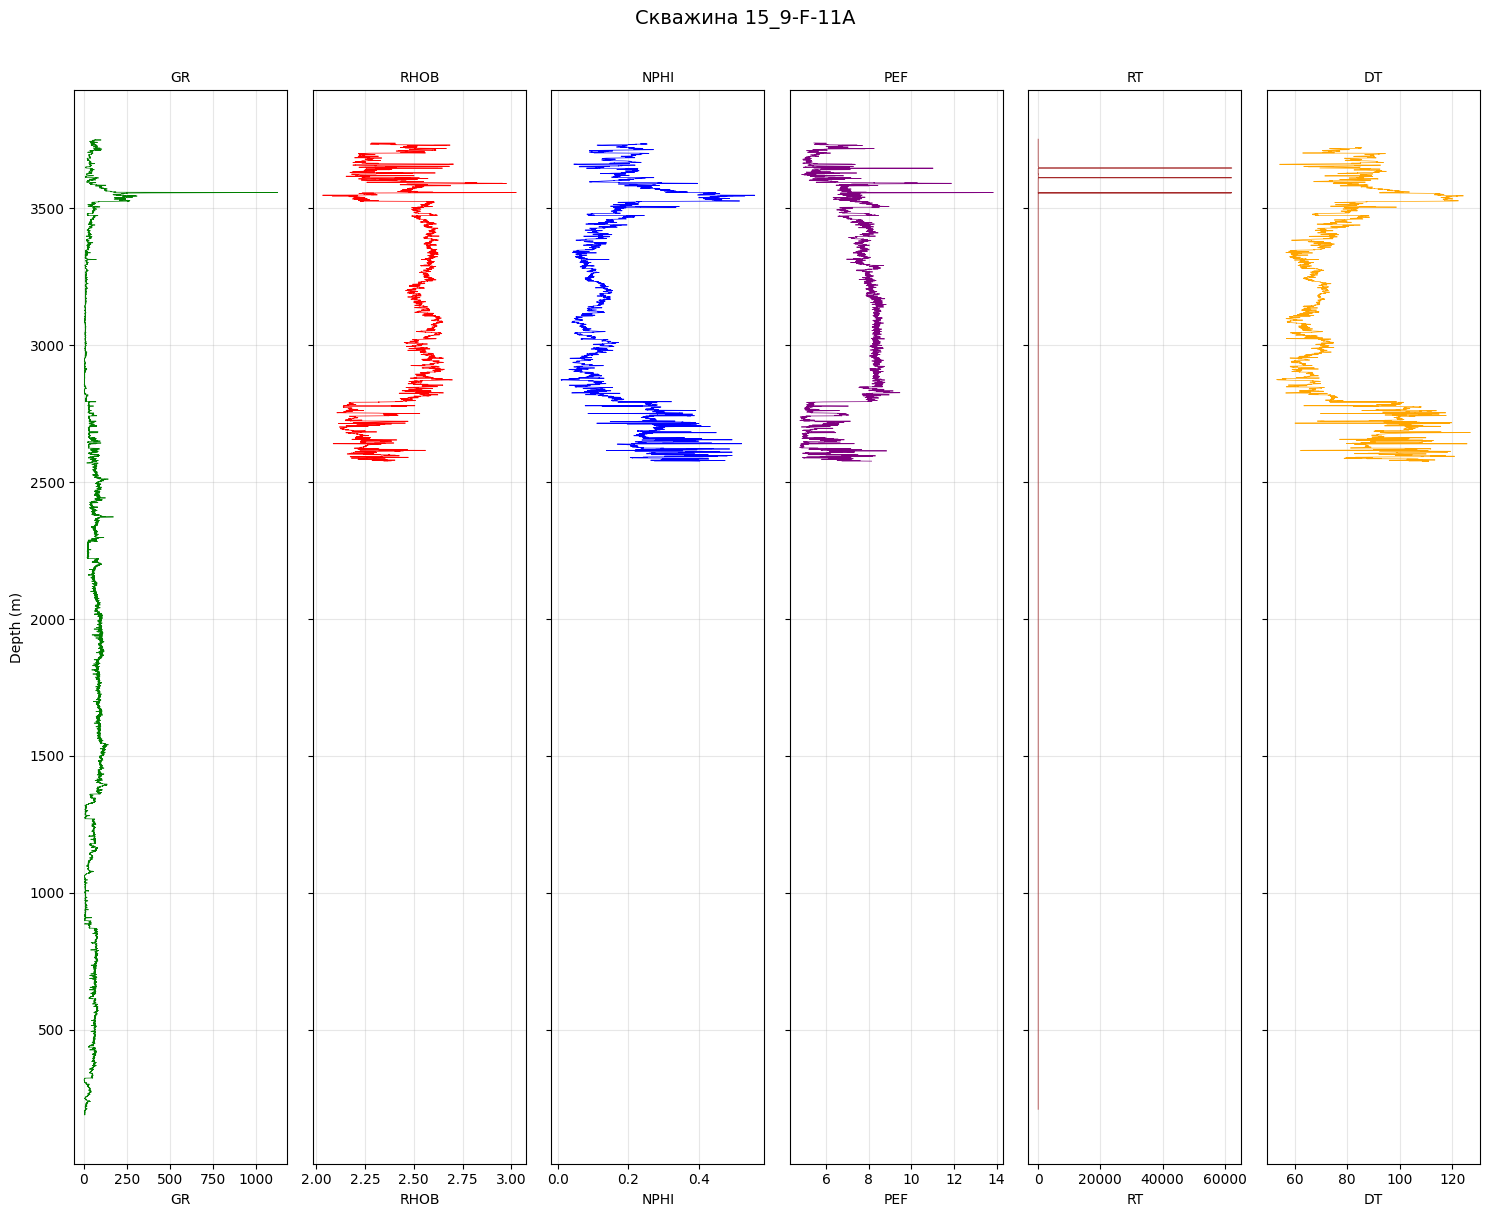

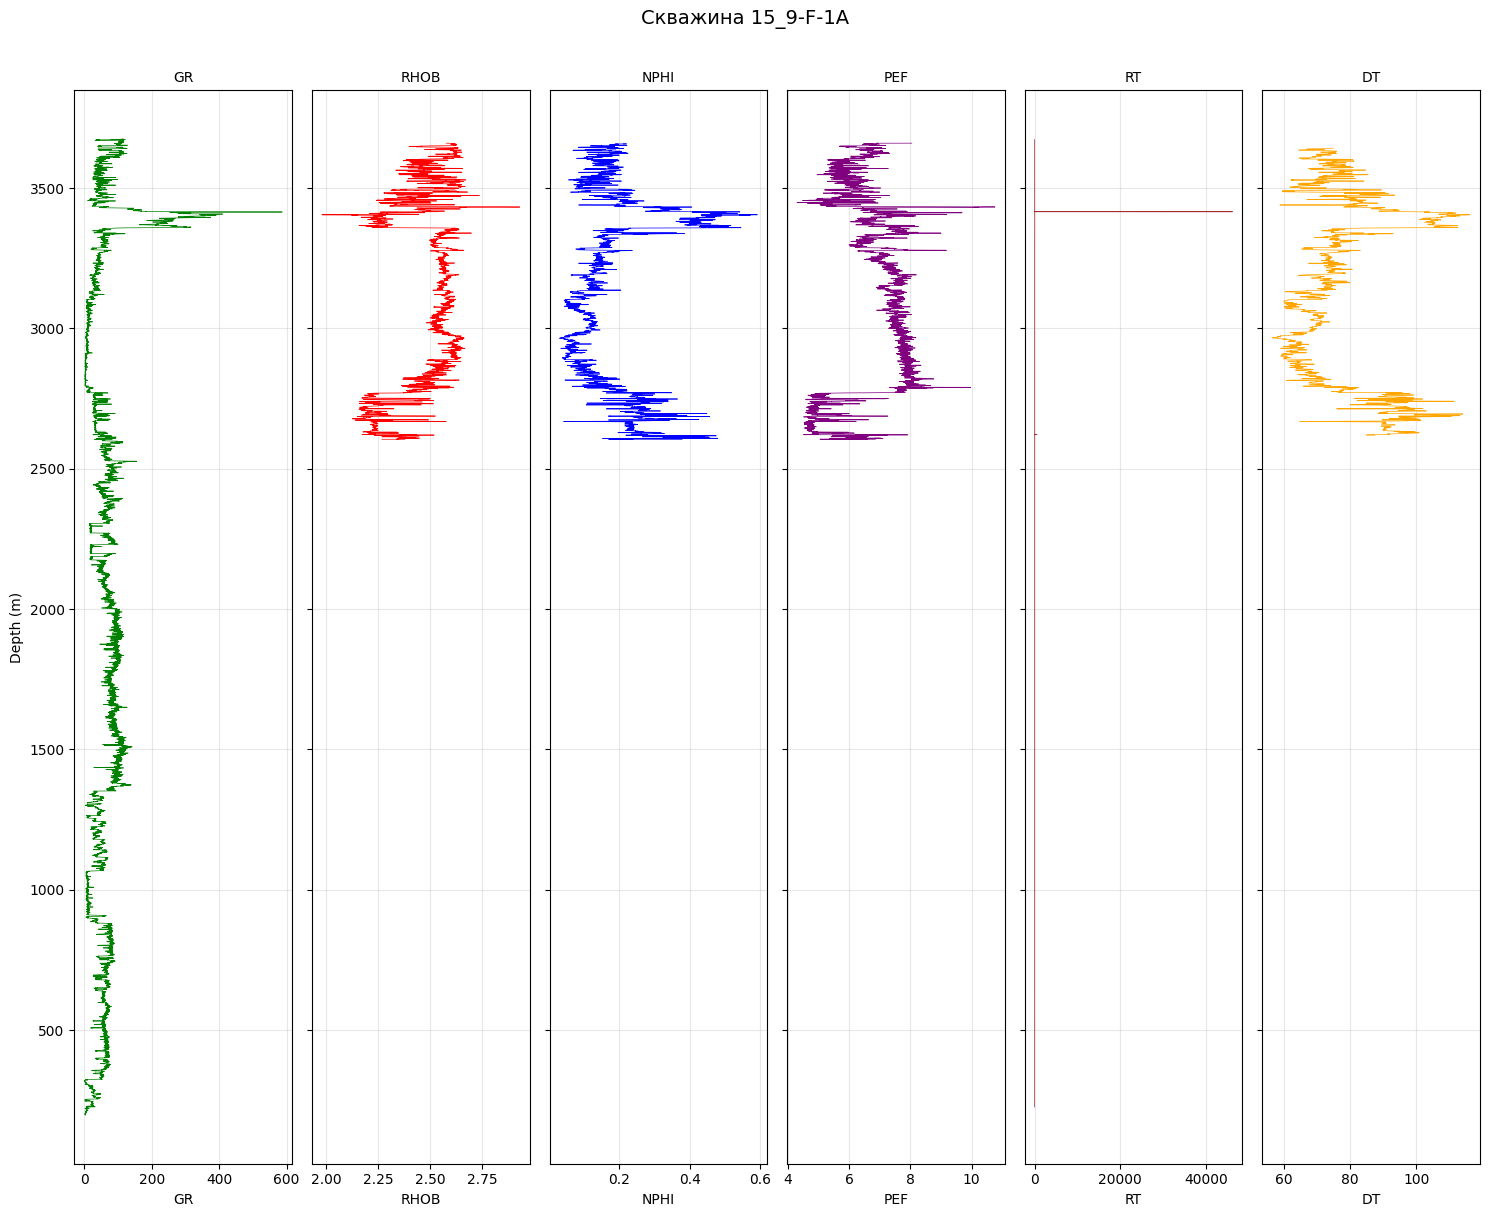

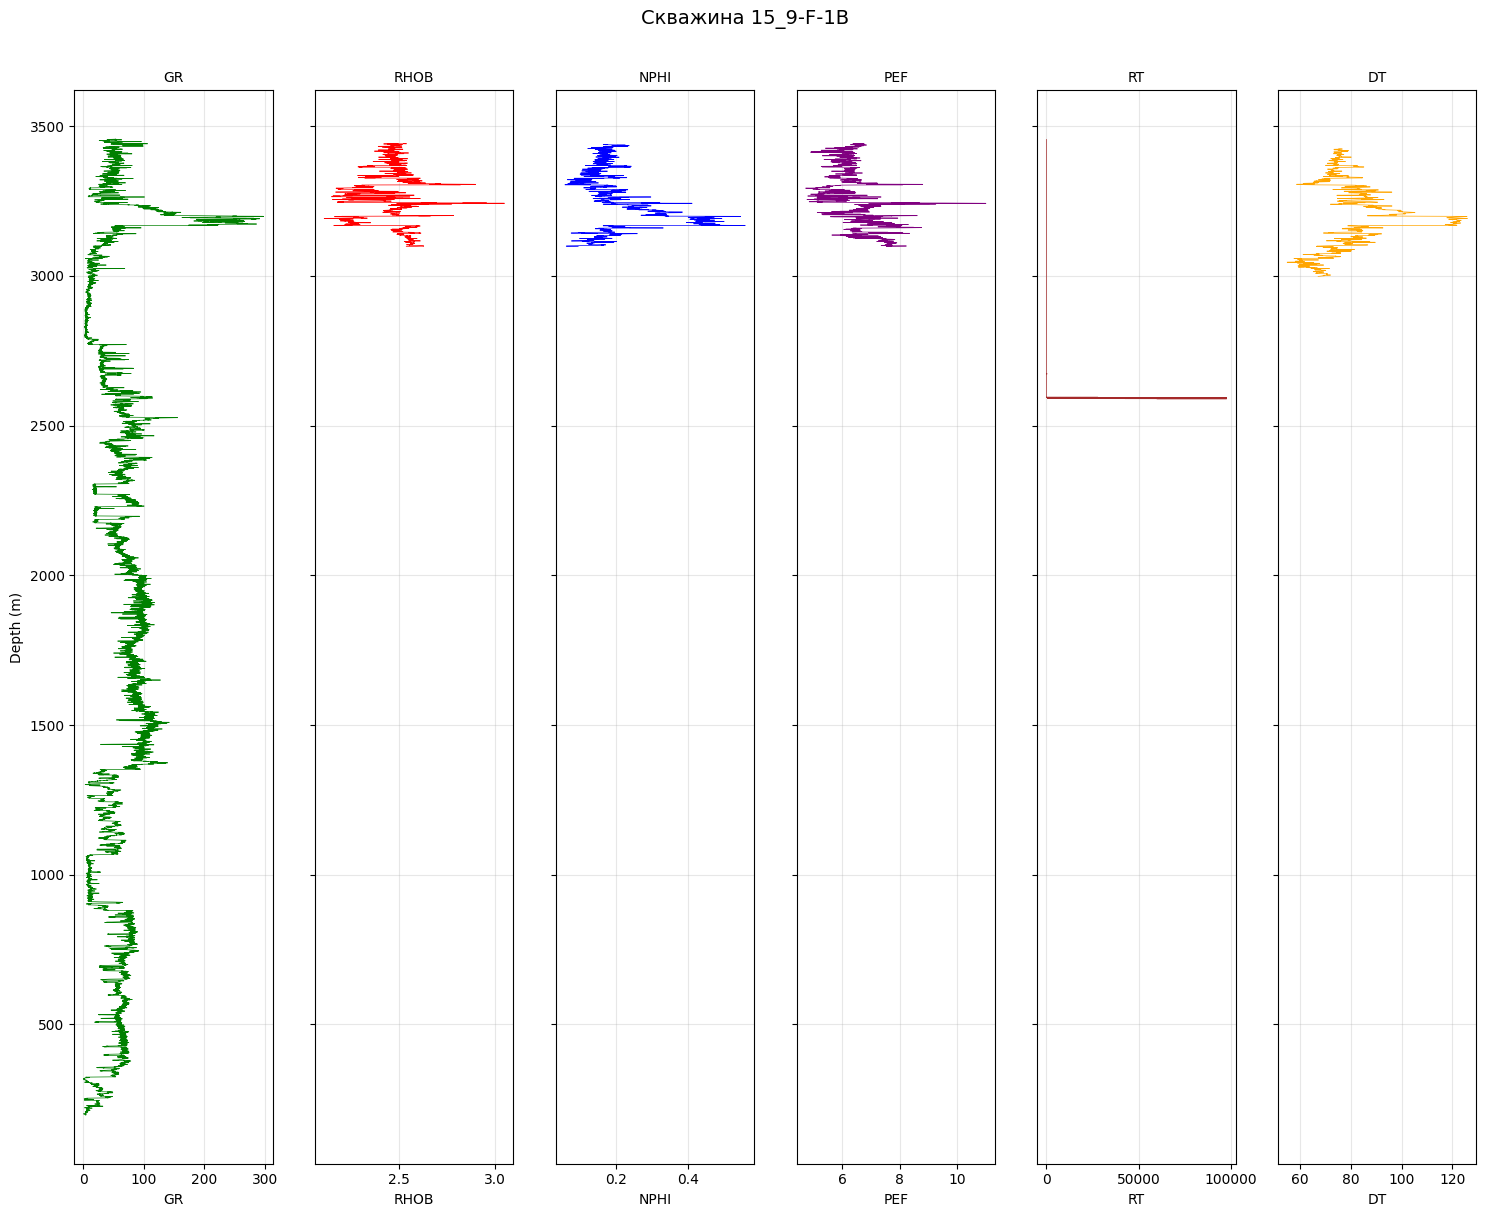

In [13]:
def plot_well_logs(df, well_name, logs=['GR', 'RHOB', 'NPHI', 'PEF', 'RT', 'DT']):
    """Стандартный формат отображения каротажных кривых"""
    # Оставляем только те кривые, которые есть
    available = [l for l in logs if l in df.columns]
    n = len(available)

    fig, axes = plt.subplots(1, n, figsize=(2.5*n, 12), sharey=True)
    fig.suptitle(f'Скважина {well_name}', fontsize=14, y=1.01)

    colors = ['green', 'red', 'blue', 'purple', 'brown', 'orange']

    for i, log in enumerate(available):
        ax = axes[i]
        data = df[[' DEPTH', log]].dropna() if ' DEPTH' in df.columns else df[['DEPTH', log]].dropna()
        depth = data['DEPTH'] if 'DEPTH' in data.columns else data[' DEPTH']

        ax.plot(data[log], depth, color=colors[i % len(colors)], linewidth=0.5)
        ax.set_xlabel(log)
        ax.set_title(log, fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.invert_yaxis()  # глубина растёт вниз

        if i == 0:
            ax.set_ylabel('Depth (m)')

    plt.tight_layout()
    plt.show()

# Рисуем для всех скважин с DT (обучающие)
for name in ['15_9-F-11A', '15_9-F-1A', '15_9-F-1B']:
    plot_well_logs(well_data[name], name)

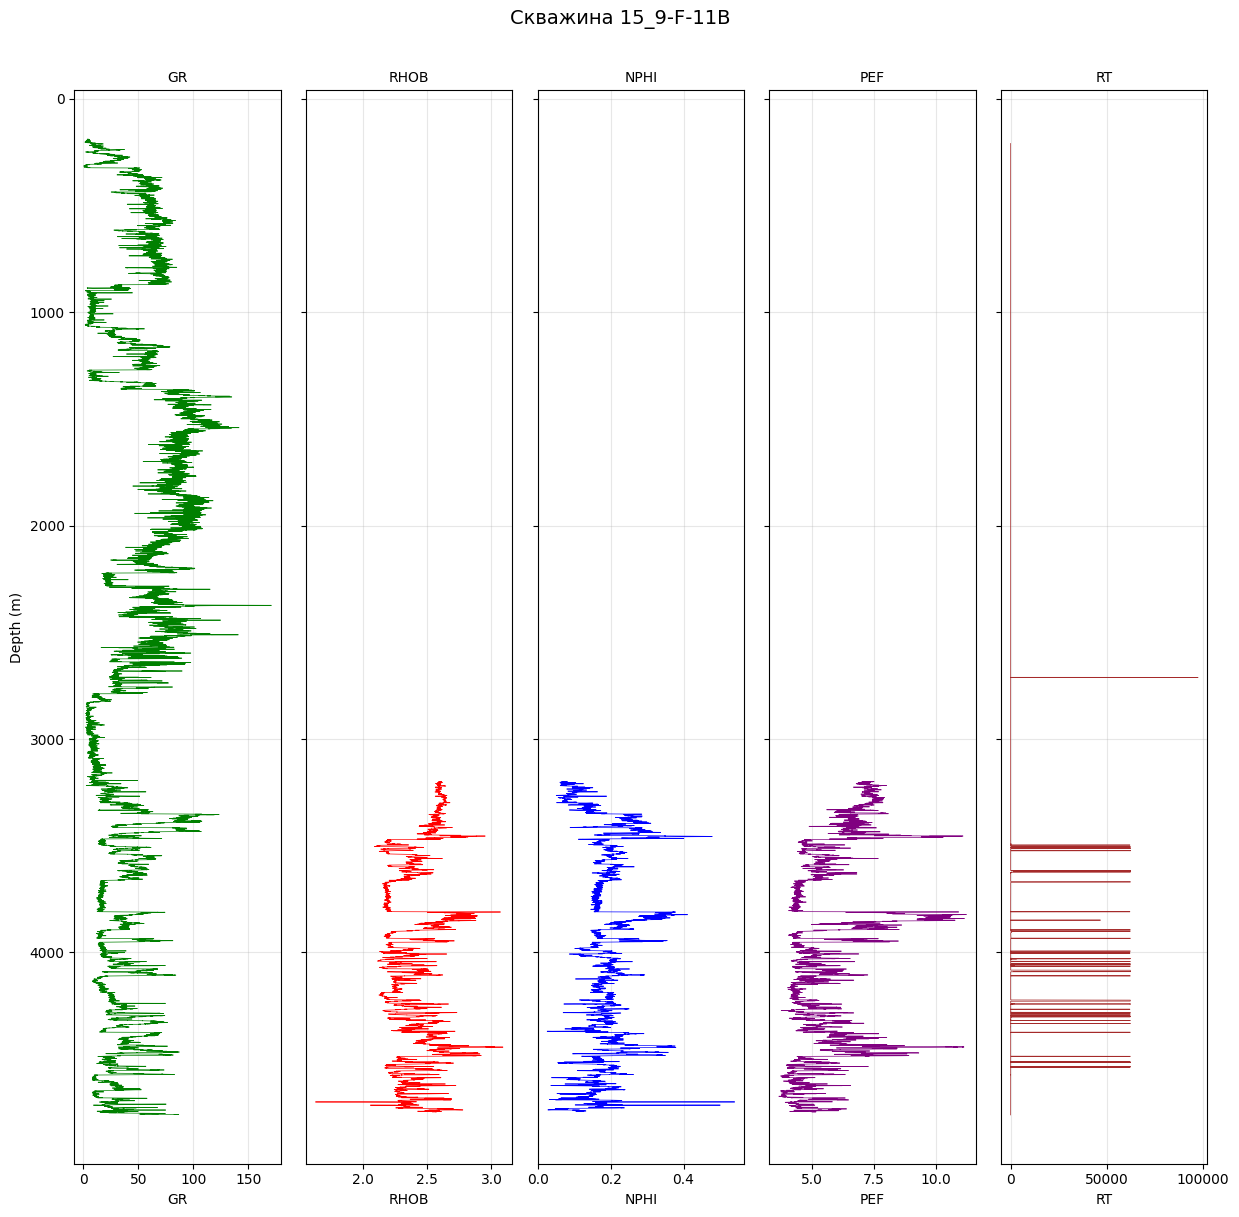

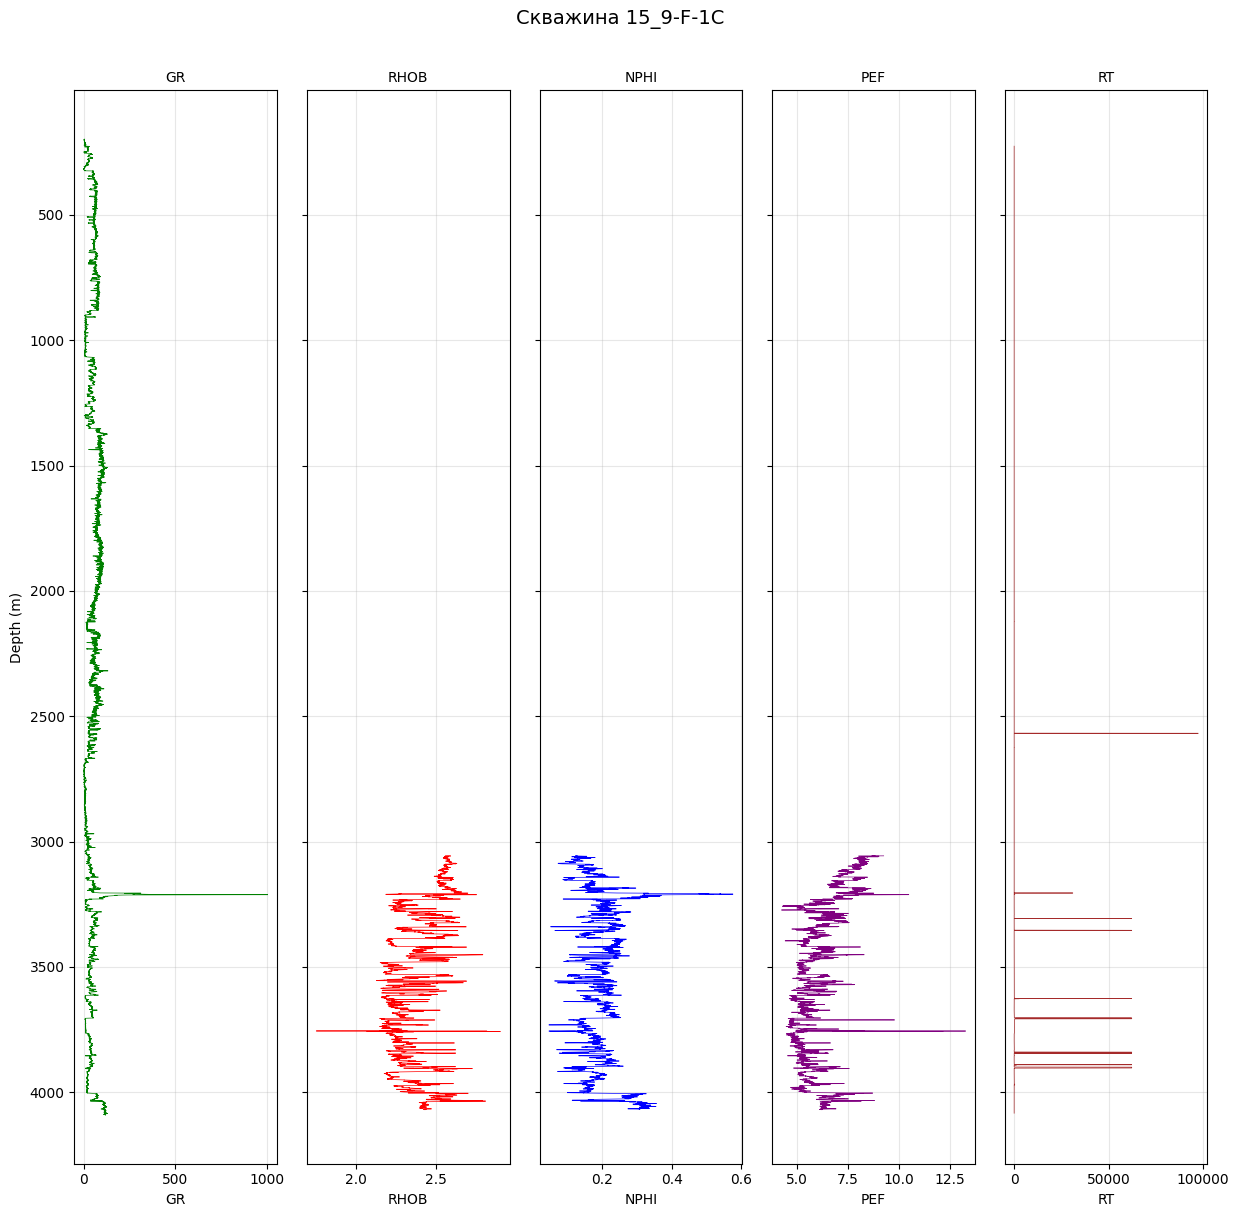

In [8]:
# И для скважин без DT (целевые)
for name in ['15_9-F-11B', '15_9-F-1C']:
    plot_well_logs(well_data[name], name, logs=['GR', 'RHOB', 'NPHI', 'PEF', 'RT'])

Шаг 4: Диапазоны глубин и статистика

In [9]:
print("Диапазоны глубин и статистика DT:\n")
for name, df in well_data.items():
    depth_min = df['DEPTH'].min()
    depth_max = df['DEPTH'].max()
    print(f"{name}:")
    print(f"  Глубина: {depth_min:.1f} — {depth_max:.1f} м")
    if 'DT' in df.columns:
        dt_clean = df['DT'].dropna()
        print(f"  DT: {dt_clean.min():.1f} — {dt_clean.max():.1f} мкс/фт")
        print(f"  DT mean: {dt_clean.mean():.1f}, std: {dt_clean.std():.1f}")
    print()

Диапазоны глубин и статистика DT:

15_9-F-11A:
  Глубина: 188.5 — 3761.9 м
  DT: 53.2 — 126.8 мкс/фт
  DT mean: 77.8, std: 15.6

15_9-F-11B:
  Глубина: 188.5 — 4770.2 м

15_9-F-1A:
  Глубина: 145.9 — 3681.9 м
  DT: 56.4 — 116.2 мкс/фт
  DT mean: 76.7, std: 12.8

15_9-F-1B:
  Глубина: 145.9 — 3464.9 м
  DT: 54.9 — 126.0 мкс/фт
  DT mean: 80.4, std: 14.7

15_9-F-1C:
  Глубина: 145.9 — 4093.9 м



Шаг 5: Корреляция фичей с DT

In [10]:
# Объединяем все скважины с DT для анализа корреляций
train_wells = []
for name in ['15_9-F-11A', '15_9-F-1A', '15_9-F-1B']:
    df = well_data[name].copy()
    df['WELL'] = name
    train_wells.append(df)

df_all = pd.concat(train_wells, ignore_index=True)

# Корреляция с DT
features_for_corr = ['GR', 'RHOB', 'NPHI', 'PEF', 'RT', 'RD', 'CALI', 'DRHO', 'ROP']
available_features = [f for f in features_for_corr if f in df_all.columns]

corr_with_dt = df_all[available_features + ['DT']].corr()['DT'].drop('DT').abs().sort_values(ascending=False)

print("Корреляция фичей с DT (по модулю):")
for feat, corr in corr_with_dt.items():
    bar = "█" * int(corr * 30)
    print(f"  {feat:<6}: {corr:.3f} {bar}")

Корреляция фичей с DT (по модулю):
  NPHI  : 0.933 ███████████████████████████
  RHOB  : 0.791 ███████████████████████
  GR    : 0.646 ███████████████████
  PEF   : 0.538 ████████████████
  DRHO  : 0.298 ████████
  ROP   : 0.230 ██████
  RD    : 0.166 ████
  CALI  : 0.160 ████
  RT    : 0.006 


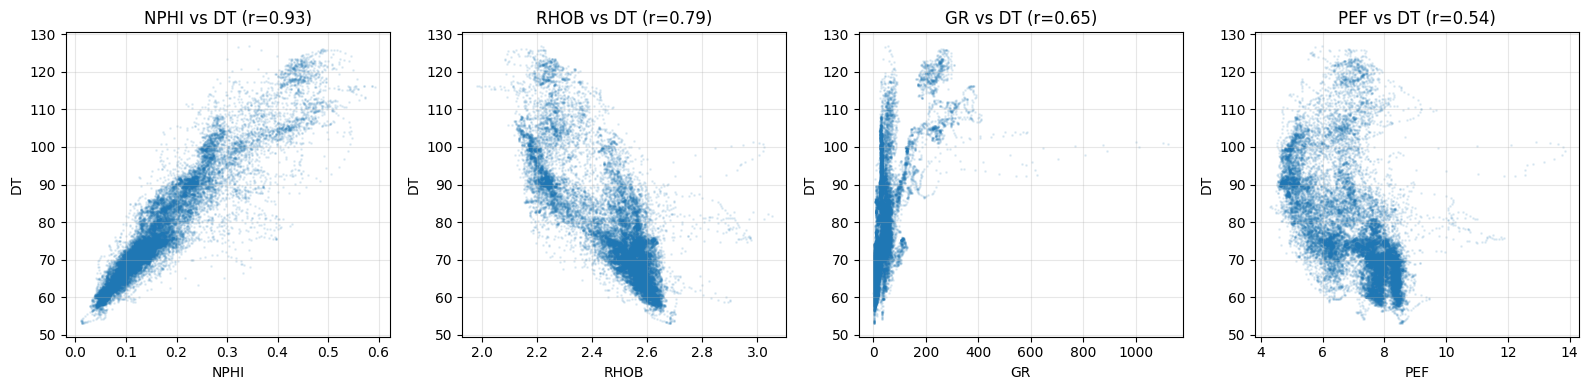

In [11]:
# Scatter plots: топ-4 фичи vs DT
top4 = corr_with_dt.head(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, feat in enumerate(top4):
    data = df_all[[feat, 'DT']].dropna()
    axes[i].scatter(data[feat], data['DT'], s=1, alpha=0.1)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('DT')
    axes[i].set_title(f'{feat} vs DT (r={corr_with_dt[feat]:.2f})')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Шаг 6: Отслеживание целевых данных

In [14]:
# Считаем сколько строк где ВСЕ ключевые фичи + DT доступны одновременно
FEATURES = ['GR', 'RHOB', 'NPHI', 'PEF', 'RT']

print("Данные где ВСЕ фичи + DT доступны одновременно:\n")

for name, df in well_data.items():
    has_dt = 'DT' in df.columns

    if has_dt:
        cols = FEATURES + ['DT', 'DEPTH']
    else:
        cols = FEATURES + ['DEPTH']

    available_cols = [c for c in cols if c in df.columns]
    clean = df[available_cols].dropna()

    if len(clean) > 0:
        depth_min = clean['DEPTH'].min()
        depth_max = clean['DEPTH'].max()
        thickness = depth_max - depth_min
    else:
        depth_min = depth_max = thickness = 0

    status = "TRAIN" if has_dt else "PREDICT"
    print(f"{name} [{status}]:")
    print(f"  Всего строк: {len(df)}")
    print(f"  Чистых строк (все фичи): {len(clean)}")
    print(f"  Интервал: {depth_min:.1f} — {depth_max:.1f} м (толщина {thickness:.1f} м)")

    if has_dt and len(clean) > 0:
        print(f"  DT: {clean['DT'].min():.1f} — {clean['DT'].max():.1f} мкс/фт")
    print()

Данные где ВСЕ фичи + DT доступны одновременно:

15_9-F-11A [TRAIN]:
  Всего строк: 35735
  Чистых строк (все фичи): 11464
  Интервал: 2577.0 — 3723.3 м (толщина 1146.3 м)
  DT: 53.2 — 126.8 мкс/фт

15_9-F-11B [PREDICT]:
  Всего строк: 45818
  Чистых строк (все фичи): 15466
  Интервал: 3198.2 — 4744.7 м (толщина 1546.5 м)

15_9-F-1A [TRAIN]:
  Всего строк: 35361
  Чистых строк (все фичи): 10224
  Интервал: 2619.8 — 3642.1 м (толщина 1022.3 м)
  DT: 56.4 — 116.2 мкс/фт

15_9-F-1B [TRAIN]:
  Всего строк: 33191
  Чистых строк (все фичи): 3262
  Интервал: 3098.5 — 3424.6 м (толщина 326.1 м)
  DT: 58.6 — 126.0 мкс/фт

15_9-F-1C [PREDICT]:
  Всего строк: 39481
  Чистых строк (все фичи): 10103
  Интервал: 3057.2 — 4067.4 м (толщина 1010.2 м)



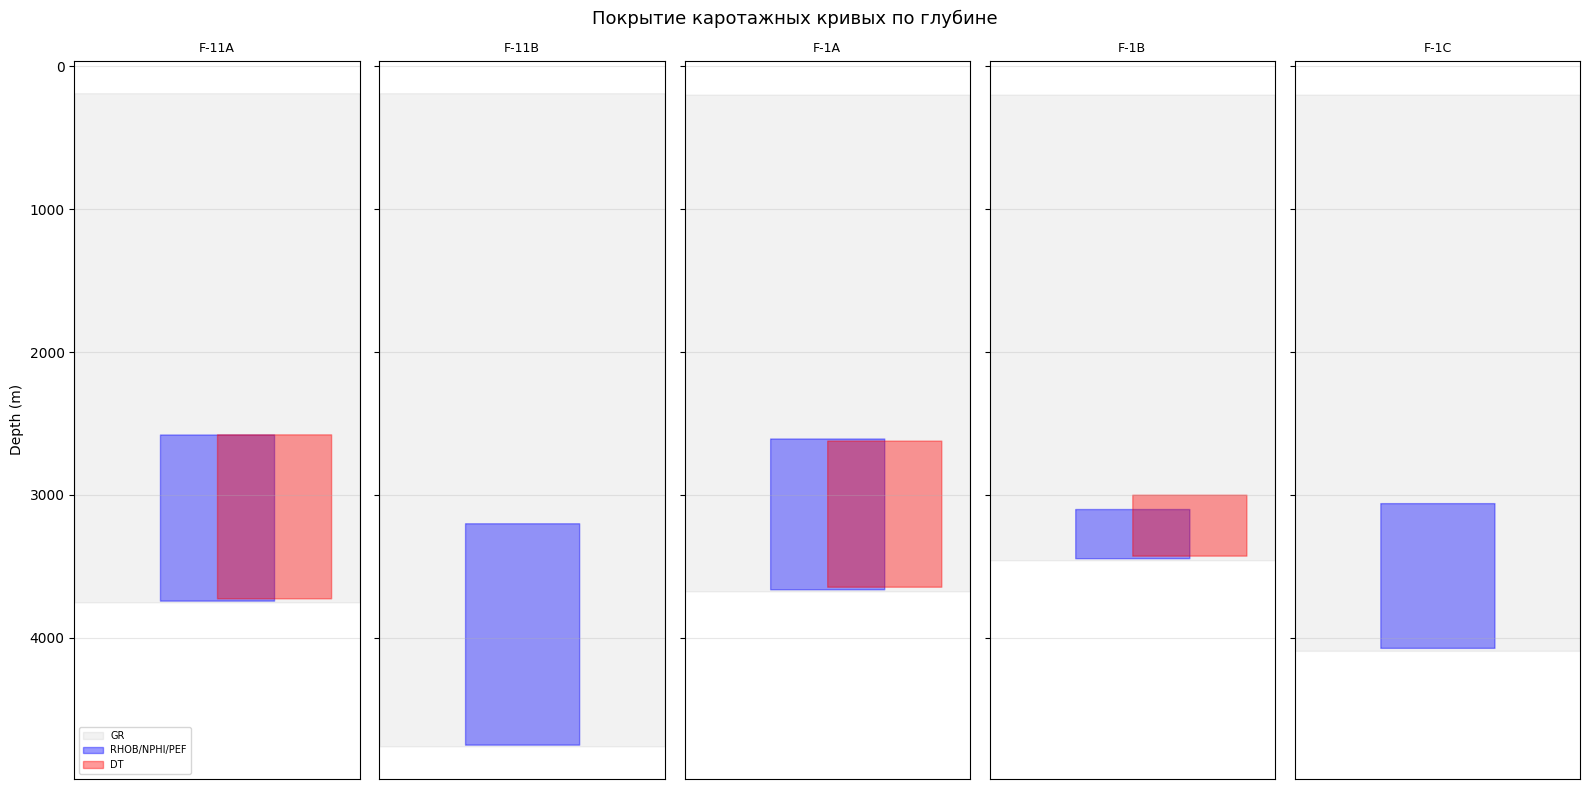

In [15]:
# Визуализация: где именно есть данные по глубине
fig, axes = plt.subplots(1, 5, figsize=(16, 8), sharey=True)

for i, (name, df) in enumerate(well_data.items()):
    ax = axes[i]

    # GR — по всей скважине (серый)
    gr_data = df[['DEPTH', 'GR']].dropna()
    ax.fill_betweenx(gr_data['DEPTH'], 0, 1, alpha=0.1, color='gray', label='GR')

    # RHOB — только интервал (синий)
    rhob_data = df[['DEPTH', 'RHOB']].dropna()
    if len(rhob_data) > 0:
        ax.fill_betweenx(rhob_data['DEPTH'], 0.3, 0.7, alpha=0.4, color='blue', label='RHOB/NPHI/PEF')

    # DT — ещё меньше (красный)
    if 'DT' in df.columns:
        dt_data = df[['DEPTH', 'DT']].dropna()
        if len(dt_data) > 0:
            ax.fill_betweenx(dt_data['DEPTH'], 0.5, 0.9, alpha=0.4, color='red', label='DT')

    ax.set_title(name.replace('15_9-', ''), fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_xticks([])
    ax.invert_yaxis()
    if i == 0:
        ax.set_ylabel('Depth (m)')
    ax.grid(True, alpha=0.3)

axes[0].legend(loc='lower left', fontsize=7)
plt.suptitle('Покрытие каротажных кривых по глубине', fontsize=13)
plt.tight_layout()
plt.show()

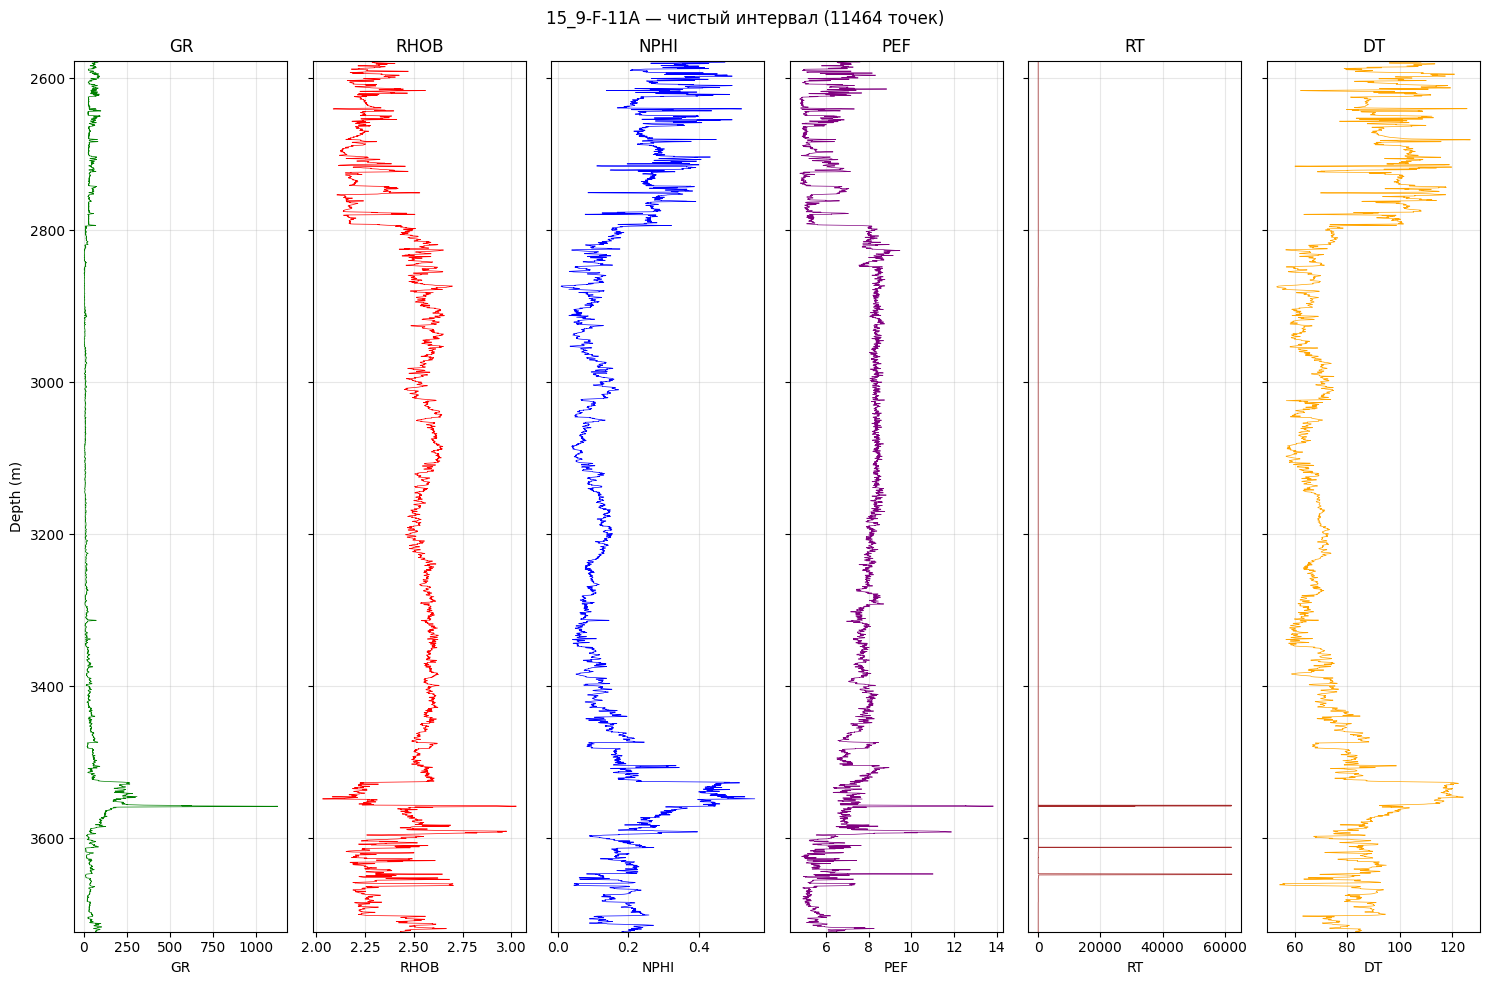

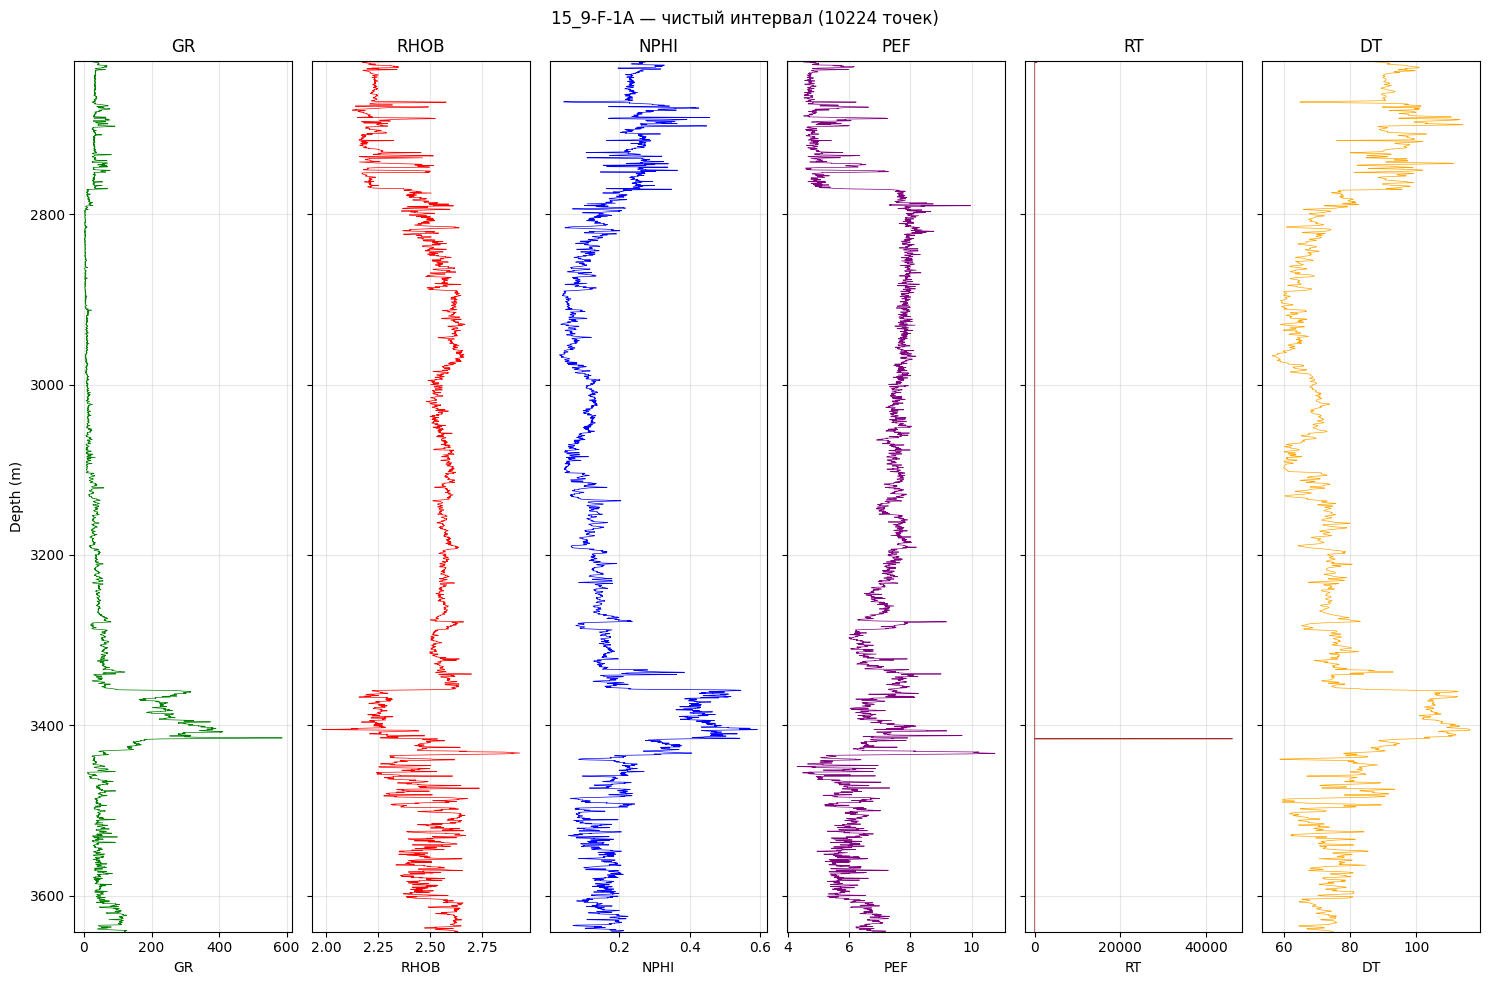

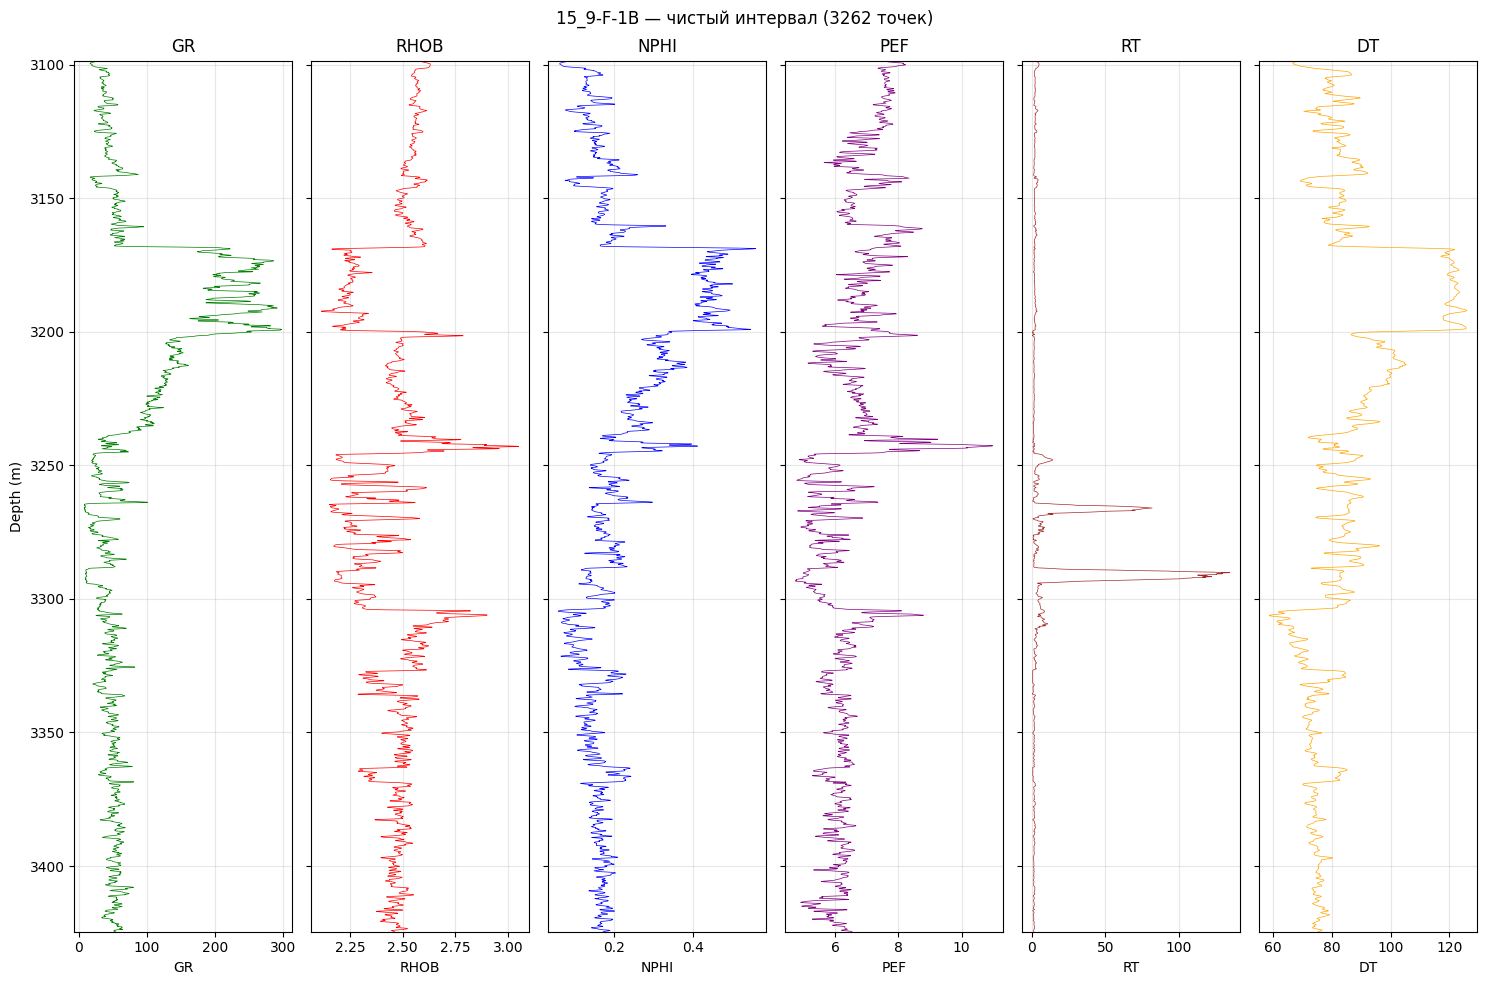

In [17]:
# Быстрый фикс: инвертируем ось у для уже построенных графиков
# Просто перестрой с этим исправлением:

for name in ['15_9-F-11A', '15_9-F-1A', '15_9-F-1B']:
    df = well_data[name]
    cols = ['DEPTH', 'GR', 'RHOB', 'NPHI', 'PEF', 'RT', 'DT']
    clean = df[cols].dropna()

    if len(clean) == 0:
        continue

    fig, axes = plt.subplots(1, 6, figsize=(15, 10), sharey=True)
    fig.suptitle(f'{name} — чистый интервал ({len(clean)} точек)', fontsize=12)

    logs = ['GR', 'RHOB', 'NPHI', 'PEF', 'RT', 'DT']
    colors = ['green', 'red', 'blue', 'purple', 'brown', 'orange']

    for i, log in enumerate(logs):
        axes[i].plot(clean[log], clean['DEPTH'], color=colors[i], linewidth=0.5)
        axes[i].set_xlabel(log)
        axes[i].set_title(log)
        axes[i].grid(True, alpha=0.3)

    # Инвертируем ОДИН РАЗ на первой оси — sharey распространит на все
    axes[0].set_ylim(clean['DEPTH'].max(), clean['DEPTH'].min())
    axes[0].set_ylabel('Depth (m)')
    plt.tight_layout()
    plt.show()

Шаг 7: Подготовка данных для модели

In [18]:
# Фичи для предсказания DT
FEATURES = ['GR', 'RHOB', 'NPHI', 'PEF']
TARGET = 'DT'

# Собираем чистые данные из обучающих скважин
train_wells_data = {}

for name in ['15_9-F-11A', '15_9-F-1A', '15_9-F-1B']:
    df = well_data[name]
    cols = ['DEPTH'] + FEATURES + [TARGET]
    clean = df[cols].dropna().reset_index(drop=True)
    train_wells_data[name] = clean
    print(f"{name}: {len(clean)} точек, глубина {clean['DEPTH'].min():.0f}–{clean['DEPTH'].max():.0f} м")

# Собираем данные для предсказания (без DT)
predict_wells_data = {}

for name in ['15_9-F-11B', '15_9-F-1C']:
    df = well_data[name]
    cols = ['DEPTH'] + FEATURES
    clean = df[cols].dropna().reset_index(drop=True)
    predict_wells_data[name] = clean
    print(f"{name}: {len(clean)} точек (для предсказания)")

15_9-F-11A: 11464 точек, глубина 2577–3723 м
15_9-F-1A: 10224 точек, глубина 2620–3642 м
15_9-F-1B: 3262 точек, глубина 3098–3425 м
15_9-F-11B: 15466 точек (для предсказания)
15_9-F-1C: 10103 точек (для предсказания)


Шаг 8: Разделение по скважинам (Leave-One-Well-Out)

In [19]:
# Стратегия:
# Train:  F-1A + F-1B   (учимся)
# Test:   F-11A         (проверяем — у неё есть DT, но модель не видела)
# Predict: F-11B, F-1C  (реальное предсказание)

train_df = pd.concat([
    train_wells_data['15_9-F-1A'],
    train_wells_data['15_9-F-1B']
], ignore_index=True)

test_df = train_wells_data['15_9-F-11A'].copy()

print(f"Train (F-1A + F-1B): {len(train_df)} точек")
print(f"Test (F-11A):        {len(test_df)} точек")

# Валидацию сделаем из train — последние 20%
val_split = int(len(train_df) * 0.8)
val_df = train_df[val_split:].reset_index(drop=True)
train_df = train_df[:val_split].reset_index(drop=True)

print(f"\nПосле разделения:")
print(f"Train: {len(train_df)}")
print(f"Val:   {len(val_df)}")
print(f"Test:  {len(test_df)} (скважина F-11A — модель НЕ видела)")

Train (F-1A + F-1B): 13486 точек
Test (F-11A):        11464 точек

После разделения:
Train: 10788
Val:   2698
Test:  11464 (скважина F-11A — модель НЕ видела)


Шаг 9: Нормализация

In [20]:
# Нормализуем по train (как всегда)
feature_mean = train_df[FEATURES].mean()
feature_std = train_df[FEATURES].std()
target_mean = train_df[TARGET].mean()
target_std = train_df[TARGET].std()

print("Параметры нормализации (train):")
for f in FEATURES:
    print(f"  {f}: mean={feature_mean[f]:.2f}, std={feature_std[f]:.2f}")
print(f"  DT: mean={target_mean:.2f}, std={target_std:.2f}")

# Нормализуем
def normalize_features(df, mean, std):
    result = df.copy()
    for col in FEATURES:
        result[col] = (result[col] - mean[col]) / std[col]
    return result

train_norm = normalize_features(train_df, feature_mean, feature_std)
val_norm = normalize_features(val_df, feature_mean, feature_std)
test_norm = normalize_features(test_df, feature_mean, feature_std)

# Target тоже нормализуем
train_norm['DT'] = (train_df['DT'] - target_mean) / target_std
val_norm['DT'] = (val_df['DT'] - target_mean) / target_std
test_norm['DT'] = (test_df['DT'] - target_mean) / target_std

Параметры нормализации (train):
  GR: mean=47.26, std=62.26
  RHOB: mean=2.49, std=0.14
  NPHI: mean=0.17, std=0.10
  PEF: mean=6.84, std=1.06
  DT: mean=76.90, std=12.58


Шаг 10: Формирование окон для LSTM

In [21]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

WINDOW = 21  # 21 точка = ~3 метра контекста сверху и снизу
# Нечётное число чтобы целевая точка была посередине окна

def make_log_windows(data, features, target, window):
    """
    Окно скользит по глубине.
    Вход: WINDOW точек каротажа (все фичи)
    Выход: DT в ЦЕНТРЕ окна

    Это отличие от временных рядов — мы смотрим и вверх и вниз,
    потому что геология двусторонняя (не как время, которое идёт в одну сторону)
    """
    half = window // 2
    X, y = [], []
    feat_vals = data[features].values
    tgt_vals = data[target].values

    for i in range(half, len(data) - half):
        X.append(feat_vals[i - half : i + half + 1])  # окно вокруг точки
        y.append(tgt_vals[i])  # DT в центре

    return np.array(X), np.array(y)

X_train, y_train = make_log_windows(train_norm, FEATURES, TARGET, WINDOW)
X_val, y_val = make_log_windows(val_norm, FEATURES, TARGET, WINDOW)
X_test, y_test = make_log_windows(test_norm, FEATURES, TARGET, WINDOW)

print(f"X_train: {X_train.shape}")  # (samples, 21, 4)
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nКаждое окно: {WINDOW} точек × {len(FEATURES)} фичи")
print(f"Предсказываем DT в центральной точке окна")

X_train: (10768, 21, 4)
X_val:   (2678, 21, 4)
X_test:  (11444, 21, 4)

Каждое окно: 21 точек × 4 фичи
Предсказываем DT в центральной точке окна


Шаг 11: Бейзлайн — Random Forest (без контекста)

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# RF видит только ТЕКУЩУЮ точку, без контекста
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(train_df[FEATURES], train_df[TARGET])

# Предсказание на тесте (F-11A)
rf_pred = rf.predict(test_df[FEATURES])
rf_mae = mean_absolute_error(test_df[TARGET], rf_pred)
rf_r2 = r2_score(test_df[TARGET], rf_pred)

# Бейзлайн "среднее"
baseline_pred = np.full(len(test_df), train_df[TARGET].mean())
baseline_mae = mean_absolute_error(test_df[TARGET], baseline_pred)

print("=" * 55)
print("БЕЙЗЛАЙНЫ на F-11A (cross-well)")
print("=" * 55)
print(f"Среднее:        MAE = {baseline_mae:.2f} мкс/фт")
print(f"Random Forest:  MAE = {rf_mae:.2f} мкс/фт, R² = {rf_r2:.3f}")

БЕЙЗЛАЙНЫ на F-11A (cross-well)
Среднее:        MAE = 12.76 мкс/фт
Random Forest:  MAE = 3.41 мкс/фт, R² = 0.893


Шаг 12: LSTM модель

In [23]:
# Тензоры
X_tr_t = torch.FloatTensor(X_train)
y_tr_t = torch.FloatTensor(y_train).unsqueeze(1)
X_vl_t = torch.FloatTensor(X_val)
y_vl_t = torch.FloatTensor(y_val).unsqueeze(1)
X_te_t = torch.FloatTensor(X_test)
y_te_t = torch.FloatTensor(y_test).unsqueeze(1)

loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=128, shuffle=True)

# Bidirectional LSTM — смотрит и вверх и вниз по разрезу
class BiLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size,
            batch_first=True,
            bidirectional=True  # ключевое отличие!
        )
        self.dropout = nn.Dropout(0.2)
        # hidden_size * 2 потому что bidirectional
        self.fc = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        # Берём выход в центральной точке окна
        center = lstm_out.shape[1] // 2
        center_out = lstm_out[:, center, :]
        out = self.dropout(center_out)
        return self.fc(out)

model = BiLSTMModel(input_size=len(FEATURES))
print(model)
print(f"Параметров: {sum(p.numel() for p in model.parameters()):,}")

BiLSTMModel(
  (lstm): LSTM(4, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)
Параметров: 35,969


In [24]:
# Обучение
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

best_vl = float('inf')
best_state = None
pat = 0
train_losses, val_losses = [], []

for epoch in range(300):
    model.train()
    el = 0
    for Xb, yb in loader:
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        el += loss.item()
    train_losses.append(el / len(loader))

    model.eval()
    with torch.no_grad():
        vl = criterion(model(X_vl_t), y_vl_t).item()
    val_losses.append(vl)

    if vl < best_vl:
        best_vl = vl
        best_state = model.state_dict().copy()
        pat = 0
    else:
        pat += 1
    if pat >= 20:
        print(f"Early stopping: эпоха {epoch+1}")
        break

    if (epoch+1) % 20 == 0:
        print(f"Эпоха {epoch+1}: train={train_losses[-1]:.6f}, val={vl:.6f}")

model.load_state_dict(best_state)
print(f"Лучший val_loss: {best_vl:.6f}")

Эпоха 20: train=0.044079, val=0.284922
Early stopping: эпоха 21
Лучший val_loss: 0.191662


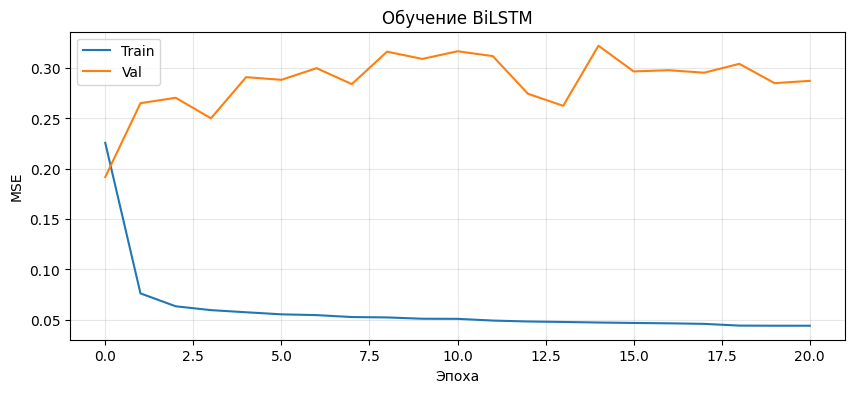

In [25]:
# Кривые обучения
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.title('Обучение BiLSTM')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Шаг 13: Оценка на контрольной скважине F-11A

In [26]:
model.eval()
with torch.no_grad():
    lstm_pred_norm = model(X_te_t).numpy().flatten()

# Денормализация
lstm_pred = lstm_pred_norm * target_std + target_mean
y_test_real = y_test * target_std + target_mean

lstm_mae = mean_absolute_error(y_test_real, lstm_pred)
lstm_r2 = r2_score(y_test_real, lstm_pred)

# Обрезаем RF предсказание чтобы совпало по длине (из-за окон)
half = WINDOW // 2
rf_pred_trimmed = rf_pred[half : len(rf_pred) - half]

print("=" * 60)
print("РЕЗУЛЬТАТЫ НА F-11A (модель НЕ видела эту скважину)")
print("=" * 60)
print(f"Среднее:         MAE = {baseline_mae:.2f} мкс/фт")
print(f"Random Forest:   MAE = {rf_mae:.2f} мкс/фт, R² = {rf_r2:.3f}")
print(f"BiLSTM:          MAE = {lstm_mae:.2f} мкс/фт, R² = {lstm_r2:.3f}")

РЕЗУЛЬТАТЫ НА F-11A (модель НЕ видела эту скважину)
Среднее:         MAE = 12.76 мкс/фт
Random Forest:   MAE = 3.41 мкс/фт, R² = 0.893
BiLSTM:          MAE = 3.31 мкс/фт, R² = 0.904


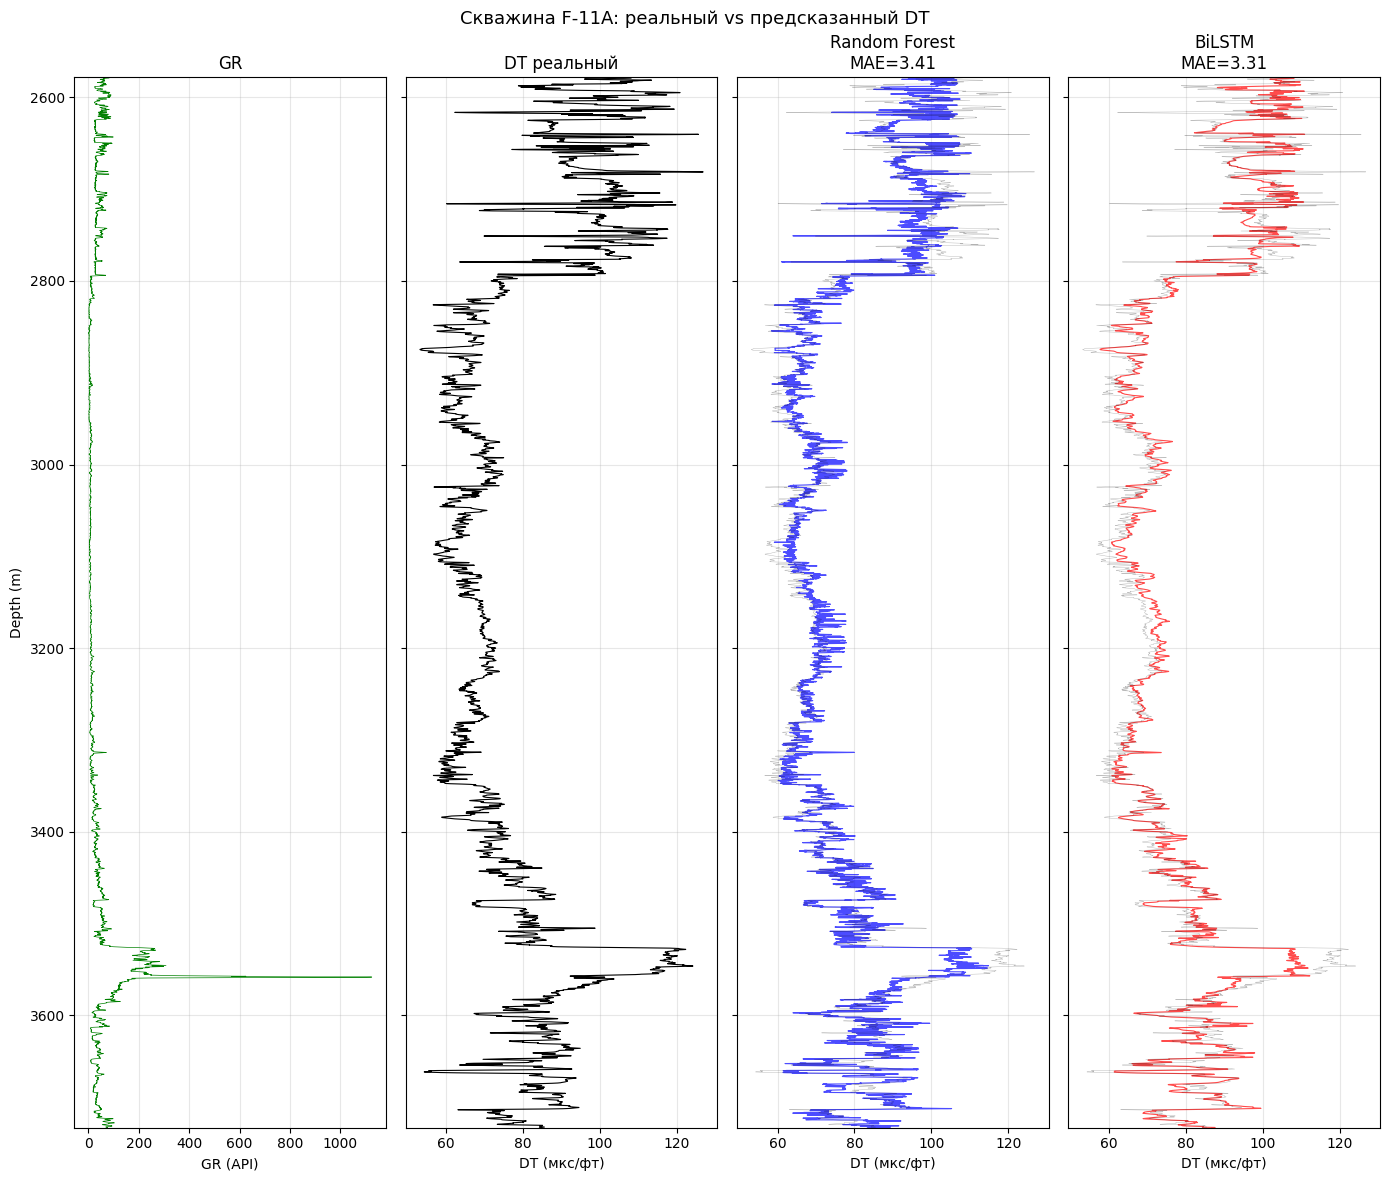

In [27]:
# Каротажный график: реальный DT vs предсказания
depth_test = test_df['DEPTH'].values[half : len(test_df) - half]

fig, axes = plt.subplots(1, 4, figsize=(14, 12), sharey=True)

# GR для контекста
axes[0].plot(test_df['GR'].values[half:-half], depth_test, 'g-', linewidth=0.5)
axes[0].set_xlabel('GR (API)')
axes[0].set_title('GR')
axes[0].set_ylim(depth_test.max(), depth_test.min())
axes[0].set_ylabel('Depth (m)')
axes[0].grid(True, alpha=0.3)

# Реальный DT
axes[1].plot(y_test_real, depth_test, 'k-', linewidth=0.8)
axes[1].set_xlabel('DT (мкс/фт)')
axes[1].set_title('DT реальный')
axes[1].grid(True, alpha=0.3)

# RF предсказание
axes[2].plot(rf_pred_trimmed, depth_test, 'b-', linewidth=0.8, alpha=0.7)
axes[2].plot(y_test_real, depth_test, 'k-', linewidth=0.3, alpha=0.3)
axes[2].set_xlabel('DT (мкс/фт)')
axes[2].set_title(f'Random Forest\nMAE={rf_mae:.2f}')
axes[2].grid(True, alpha=0.3)

# LSTM предсказание
axes[3].plot(lstm_pred, depth_test, 'r-', linewidth=0.8, alpha=0.7)
axes[3].plot(y_test_real, depth_test, 'k-', linewidth=0.3, alpha=0.3)
axes[3].set_xlabel('DT (мкс/фт)')
axes[3].set_title(f'BiLSTM\nMAE={lstm_mae:.2f}')
axes[3].grid(True, alpha=0.3)

plt.suptitle('Скважина F-11A: реальный vs предсказанный DT', fontsize=13)
plt.tight_layout()
plt.show()

Шаг 14: Улучшение LSTM

In [28]:
# Улучшение 1: Уменьшаем окно — меньше сглаживания
# Улучшение 2: Добавляем ГЛУБИНУ как фичу
# Улучшение 3: Добавляем ПРОИЗВОДНЫЕ (скорость изменения кривых)

# Добавляем производные — они ловят ГРАНИЦЫ пластов
def add_gradient_features(df, features):
    """Добавляет градиент (разность) каждой кривой"""
    result = df.copy()
    for f in features:
        result[f'{f}_grad'] = result[f].diff().fillna(0)
    return result

train_df_aug = add_gradient_features(
    pd.concat([train_wells_data['15_9-F-1A'], train_wells_data['15_9-F-1B']], ignore_index=True),
    FEATURES
)
test_df_aug = add_gradient_features(train_wells_data['15_9-F-11A'], FEATURES)

# Расширенный набор фичей
FEATURES_AUG = FEATURES + [f'{f}_grad' for f in FEATURES]

print(f"Фичи: {FEATURES_AUG}")
print(f"Было {len(FEATURES)} фичей, стало {len(FEATURES_AUG)}")

# Нормализация расширенных фичей
val_split2 = int(len(train_df_aug) * 0.8)
val_df_aug = train_df_aug[val_split2:].reset_index(drop=True)
train_df_aug2 = train_df_aug[:val_split2].reset_index(drop=True)

feat_mean2 = train_df_aug2[FEATURES_AUG].mean()
feat_std2 = train_df_aug2[FEATURES_AUG].std()
feat_std2[feat_std2 == 0] = 1

for col in FEATURES_AUG:
    train_df_aug2[col] = (train_df_aug2[col] - feat_mean2[col]) / feat_std2[col]
    val_df_aug[col] = (val_df_aug[col] - feat_mean2[col]) / feat_std2[col]
    test_df_aug[col] = (test_df_aug[col] - feat_mean2[col]) / feat_std2[col]

train_df_aug2['DT_norm'] = (train_df_aug2['DT'] - target_mean) / target_std
val_df_aug['DT_norm'] = (val_df_aug['DT'] - target_mean) / target_std
test_df_aug['DT_norm'] = (test_df_aug['DT'] - target_mean) / target_std

Фичи: ['GR', 'RHOB', 'NPHI', 'PEF', 'GR_grad', 'RHOB_grad', 'NPHI_grad', 'PEF_grad']
Было 4 фичей, стало 8


In [29]:
# Меньшее окно + расширенные фичи
WINDOW2 = 11  # было 21, теперь 11 — меньше сглаживания

def make_log_windows_v2(data, features, target_col, window):
    half = window // 2
    X, y = [], []
    feat_vals = data[features].values
    tgt_vals = data[target_col].values
    for i in range(half, len(data) - half):
        X.append(feat_vals[i - half : i + half + 1])
        y.append(tgt_vals[i])
    return np.array(X), np.array(y)

X_tr2, y_tr2 = make_log_windows_v2(train_df_aug2, FEATURES_AUG, 'DT_norm', WINDOW2)
X_vl2, y_vl2 = make_log_windows_v2(val_df_aug, FEATURES_AUG, 'DT_norm', WINDOW2)
X_te2, y_te2 = make_log_windows_v2(test_df_aug, FEATURES_AUG, 'DT_norm', WINDOW2)

print(f"X_train: {X_tr2.shape}")
print(f"X_val:   {X_vl2.shape}")
print(f"X_test:  {X_te2.shape}")

X_train: (10778, 11, 8)
X_val:   (2688, 11, 8)
X_test:  (11454, 11, 8)


In [30]:
# Обучаем улучшенную модель
X_tr2_t = torch.FloatTensor(X_tr2)
y_tr2_t = torch.FloatTensor(y_tr2).unsqueeze(1)
X_vl2_t = torch.FloatTensor(X_vl2)
y_vl2_t = torch.FloatTensor(y_vl2).unsqueeze(1)
X_te2_t = torch.FloatTensor(X_te2)

loader2 = DataLoader(TensorDataset(X_tr2_t, y_tr2_t), batch_size=128, shuffle=True)

model2 = BiLSTMModel(input_size=len(FEATURES_AUG), hidden_size=64)
opt2 = torch.optim.Adam(model2.parameters(), lr=0.001)
crit2 = nn.MSELoss()

best_vl2 = float('inf')
best_state2 = None
pat2 = 0

for epoch in range(300):
    model2.train()
    for Xb, yb in loader2:
        opt2.zero_grad()
        crit2(model2(Xb), yb).backward()
        opt2.step()

    model2.eval()
    with torch.no_grad():
        vl = crit2(model2(X_vl2_t), y_vl2_t).item()

    if vl < best_vl2:
        best_vl2 = vl
        best_state2 = model2.state_dict().copy()
        pat2 = 0
    else:
        pat2 += 1
    if pat2 >= 20:
        print(f"Early stopping: эпоха {epoch+1}")
        break

    if (epoch+1) % 20 == 0:
        print(f"Эпоха {epoch+1}: val={vl:.6f}")

model2.load_state_dict(best_state2)
print(f"Лучший val_loss: {best_vl2:.6f}")

Эпоха 20: val=0.301989
Early stopping: эпоха 21
Лучший val_loss: 0.215986


In [31]:
# Оценка
model2.eval()
with torch.no_grad():
    pred2_norm = model2(X_te2_t).numpy().flatten()

pred2_real = pred2_norm * target_std + target_mean
y_te2_real = y_te2 * target_std + target_mean

mae2 = mean_absolute_error(y_te2_real, pred2_real)
r2_2 = r2_score(y_te2_real, pred2_real)

half2 = WINDOW2 // 2
depth_test2 = test_df_aug['DEPTH'].values[half2 : len(test_df_aug) - half2]

print("=" * 60)
print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ НА F-11A")
print("=" * 60)
print(f"Среднее:                    MAE = {baseline_mae:.2f} мкс/фт")
print(f"Random Forest:              MAE = {rf_mae:.2f} мкс/фт, R² = {rf_r2:.3f}")
print(f"BiLSTM (окно 21):           MAE = {lstm_mae:.2f} мкс/фт, R² = {lstm_r2:.3f}")
print(f"BiLSTM v2 (окно 11 + grad): MAE = {mae2:.2f} мкс/фт, R² = {r2_2:.3f}")

СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ НА F-11A
Среднее:                    MAE = 12.76 мкс/фт
Random Forest:              MAE = 3.41 мкс/фт, R² = 0.893
BiLSTM (окно 21):           MAE = 3.31 мкс/фт, R² = 0.904
BiLSTM v2 (окно 11 + grad): MAE = 3.21 мкс/фт, R² = 0.895


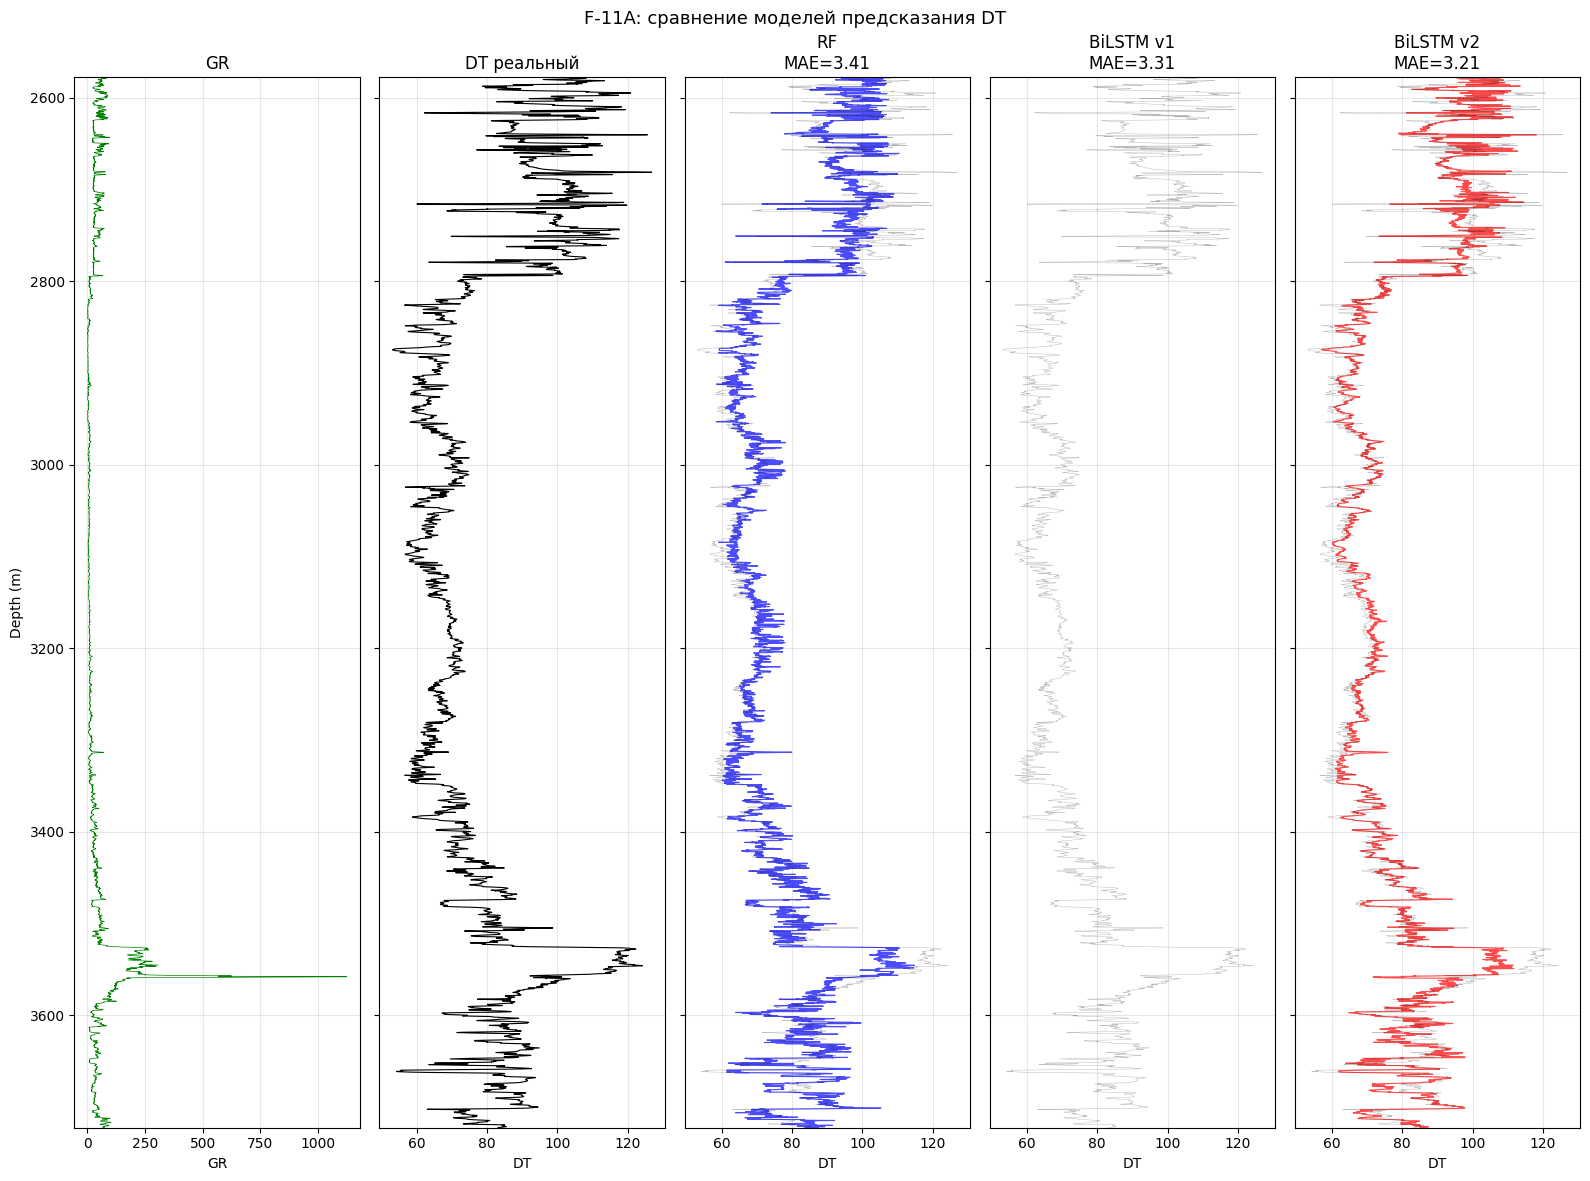

In [33]:
# Финальный каротажный график
fig, axes = plt.subplots(1, 5, figsize=(16, 12), sharey=True)

# GR
gr_vals = test_df_aug['GR'].values[half2:-half2] * feat_std2['GR'] + feat_mean2['GR']
axes[0].plot(gr_vals, depth_test2, 'g-', linewidth=0.5)
axes[0].set_xlabel('GR')
axes[0].set_title('GR')
axes[0].set_ylim(depth_test2.max(), depth_test2.min())
axes[0].set_ylabel('Depth (m)')
axes[0].grid(True, alpha=0.3)

# Реальный DT
axes[1].plot(y_te2_real, depth_test2, 'k-', linewidth=0.8)
axes[1].set_xlabel('DT')
axes[1].set_title('DT реальный')
axes[1].grid(True, alpha=0.3)

# RF
rf_pred_trim2 = rf_pred[half2 : len(rf_pred) - half2]
axes[2].plot(rf_pred_trim2, depth_test2, 'b-', linewidth=0.8, alpha=0.7)
axes[2].plot(y_te2_real, depth_test2, 'k-', linewidth=0.3, alpha=0.3)
axes[2].set_xlabel('DT')
axes[2].set_title(f'RF\nMAE={rf_mae:.2f}')
axes[2].grid(True, alpha=0.3)

# BiLSTM v1
lstm_trim = lstm_pred[half2-half : -(half-half2)] if half != half2 else lstm_pred
if len(lstm_trim) > len(depth_test2):
    lstm_trim = lstm_trim[:len(depth_test2)]
axes[3].plot(lstm_trim, depth_test2[:len(lstm_trim)], 'y-', linewidth=0.8, alpha=0.7)
axes[3].plot(y_te2_real, depth_test2, 'k-', linewidth=0.3, alpha=0.3)
axes[3].set_xlabel('DT')
axes[3].set_title(f'BiLSTM v1\nMAE={lstm_mae:.2f}')
axes[3].grid(True, alpha=0.3)

# BiLSTM v2
axes[4].plot(pred2_real, depth_test2, 'r-', linewidth=0.8, alpha=0.7)
axes[4].plot(y_te2_real, depth_test2, 'k-', linewidth=0.3, alpha=0.3)
axes[4].set_xlabel('DT')
axes[4].set_title(f'BiLSTM v2\nMAE={mae2:.2f}')
axes[4].grid(True, alpha=0.3)

plt.suptitle('F-11A: сравнение моделей предсказания DT', fontsize=13)
plt.tight_layout()
plt.show()

Шаг 15: Гибрид — RF + LSTM

In [34]:
# Способ 1: Простое усреднение (ensemble)
# Обрезаем до одинаковой длины
min_len = min(len(pred2_real), len(rf_pred_trim2), len(y_te2_real))
pred2_cut = pred2_real[:min_len]
rf_cut = rf_pred_trim2[:min_len]
y_true_cut = y_te2_real[:min_len]
depth_cut = depth_test2[:min_len]

ensemble_pred = 0.5 * rf_cut + 0.5 * pred2_cut
ensemble_mae = mean_absolute_error(y_true_cut, ensemble_pred)
ensemble_r2 = r2_score(y_true_cut, ensemble_pred)

# Способ 2: Взвешенное усреднение (больше веса RF)
ensemble_70_pred = 0.7 * rf_cut + 0.3 * pred2_cut
ensemble_70_mae = mean_absolute_error(y_true_cut, ensemble_70_pred)
ensemble_70_r2 = r2_score(y_true_cut, ensemble_70_pred)

# Способ 3: Подбираем оптимальный вес
from scipy.optimize import minimize_scalar

def ensemble_loss(alpha):
    pred = alpha * rf_cut + (1 - alpha) * pred2_cut
    return mean_absolute_error(y_true_cut, pred)

result = minimize_scalar(ensemble_loss, bounds=(0, 1), method='bounded')
best_alpha = result.x
best_ensemble = best_alpha * rf_cut + (1 - best_alpha) * pred2_cut
best_ensemble_mae = mean_absolute_error(y_true_cut, best_ensemble)
best_ensemble_r2 = r2_score(y_true_cut, best_ensemble)

print("=" * 65)
print("ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ ПОДХОДОВ НА F-11A")
print("=" * 65)
print(f"{'Модель':<35} {'MAE':>8} {'R²':>8}")
print("-" * 65)
print(f"{'Среднее (бейзлайн)':<35} {baseline_mae:>8.2f} {'—':>8}")
print(f"{'Random Forest':<35} {rf_mae:>8.2f} {rf_r2:>8.3f}")
print(f"{'BiLSTM v1 (окно 21)':<35} {lstm_mae:>8.2f} {lstm_r2:>8.3f}")
print(f"{'BiLSTM v2 (окно 11 + grad)':<35} {mae2:>8.2f} {r2_2:>8.3f}")
print(f"{'Ensemble 50/50 (RF + LSTM)':<35} {ensemble_mae:>8.2f} {ensemble_r2:>8.3f}")
print(f"{'Ensemble 70/30 (RF + LSTM)':<35} {ensemble_70_mae:>8.2f} {ensemble_70_r2:>8.3f}")
print(f"{'Ensemble оптимальный ({best_alpha:.0%} RF)':<35} {best_ensemble_mae:>8.2f} {best_ensemble_r2:>8.3f}")
print("=" * 65)

ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ ПОДХОДОВ НА F-11A
Модель                                   MAE       R²
-----------------------------------------------------------------
Среднее (бейзлайн)                     12.76        —
Random Forest                           3.41    0.893
BiLSTM v1 (окно 21)                     3.31    0.904
BiLSTM v2 (окно 11 + grad)              3.21    0.895
Ensemble 50/50 (RF + LSTM)              3.13    0.904
Ensemble 70/30 (RF + LSTM)              3.20    0.902
Ensemble оптимальный ({best_alpha:.0%} RF)     3.12    0.904


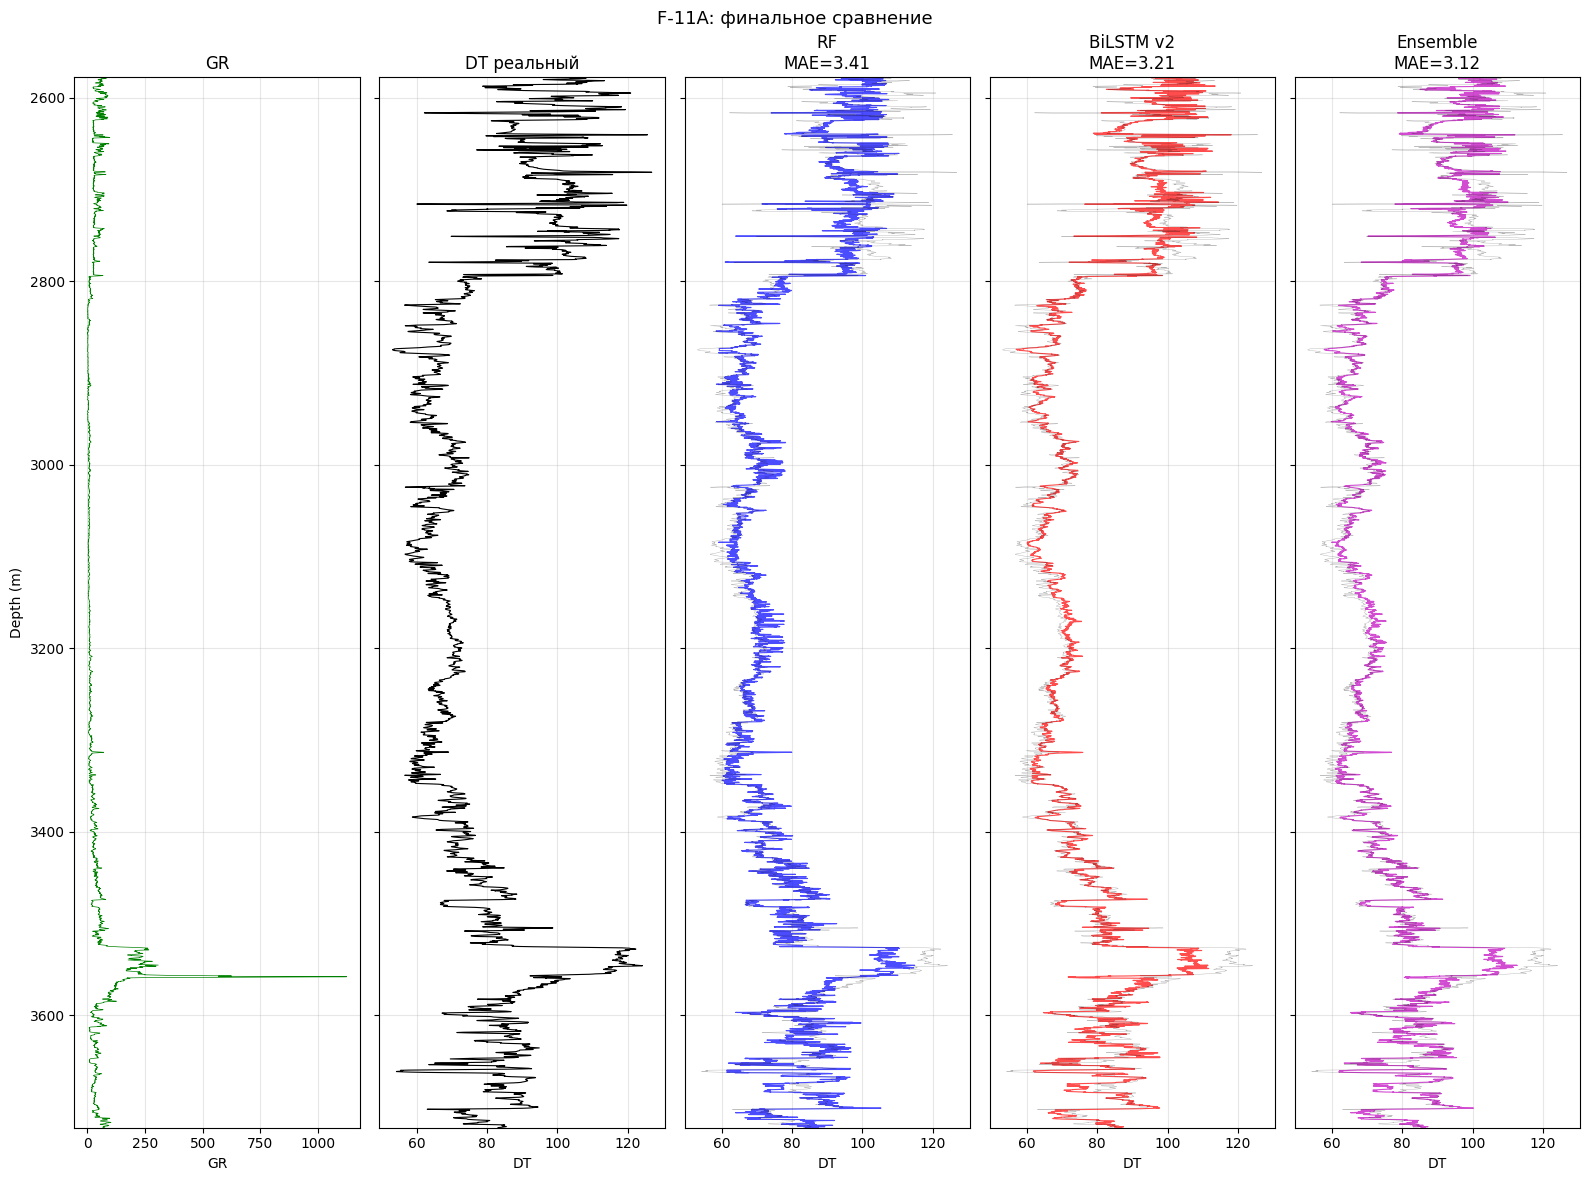

In [35]:
# Финальный каротажный график: лучшие модели
fig, axes = plt.subplots(1, 5, figsize=(16, 12), sharey=True)

axes[0].plot(gr_vals[:min_len], depth_cut, 'g-', linewidth=0.5)
axes[0].set_xlabel('GR')
axes[0].set_title('GR')
axes[0].set_ylim(depth_cut.max(), depth_cut.min())
axes[0].set_ylabel('Depth (m)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(y_true_cut, depth_cut, 'k-', linewidth=0.8)
axes[1].set_xlabel('DT')
axes[1].set_title('DT реальный')
axes[1].grid(True, alpha=0.3)

axes[2].plot(rf_cut, depth_cut, 'b-', linewidth=0.8, alpha=0.7)
axes[2].plot(y_true_cut, depth_cut, 'k-', linewidth=0.3, alpha=0.3)
axes[2].set_xlabel('DT')
axes[2].set_title(f'RF\nMAE={rf_mae:.2f}')
axes[2].grid(True, alpha=0.3)

axes[3].plot(pred2_cut, depth_cut, 'r-', linewidth=0.8, alpha=0.7)
axes[3].plot(y_true_cut, depth_cut, 'k-', linewidth=0.3, alpha=0.3)
axes[3].set_xlabel('DT')
axes[3].set_title(f'BiLSTM v2\nMAE={mae2:.2f}')
axes[3].grid(True, alpha=0.3)

axes[4].plot(best_ensemble, depth_cut, 'm-', linewidth=0.8, alpha=0.7)
axes[4].plot(y_true_cut, depth_cut, 'k-', linewidth=0.3, alpha=0.3)
axes[4].set_xlabel('DT')
axes[4].set_title(f'Ensemble\nMAE={best_ensemble_mae:.2f}')
axes[4].grid(True, alpha=0.3)

plt.suptitle('F-11A: финальное сравнение', fontsize=13)
plt.tight_layout()
plt.show()

Шаг 16: Предсказание DT на скважинах без каротажа

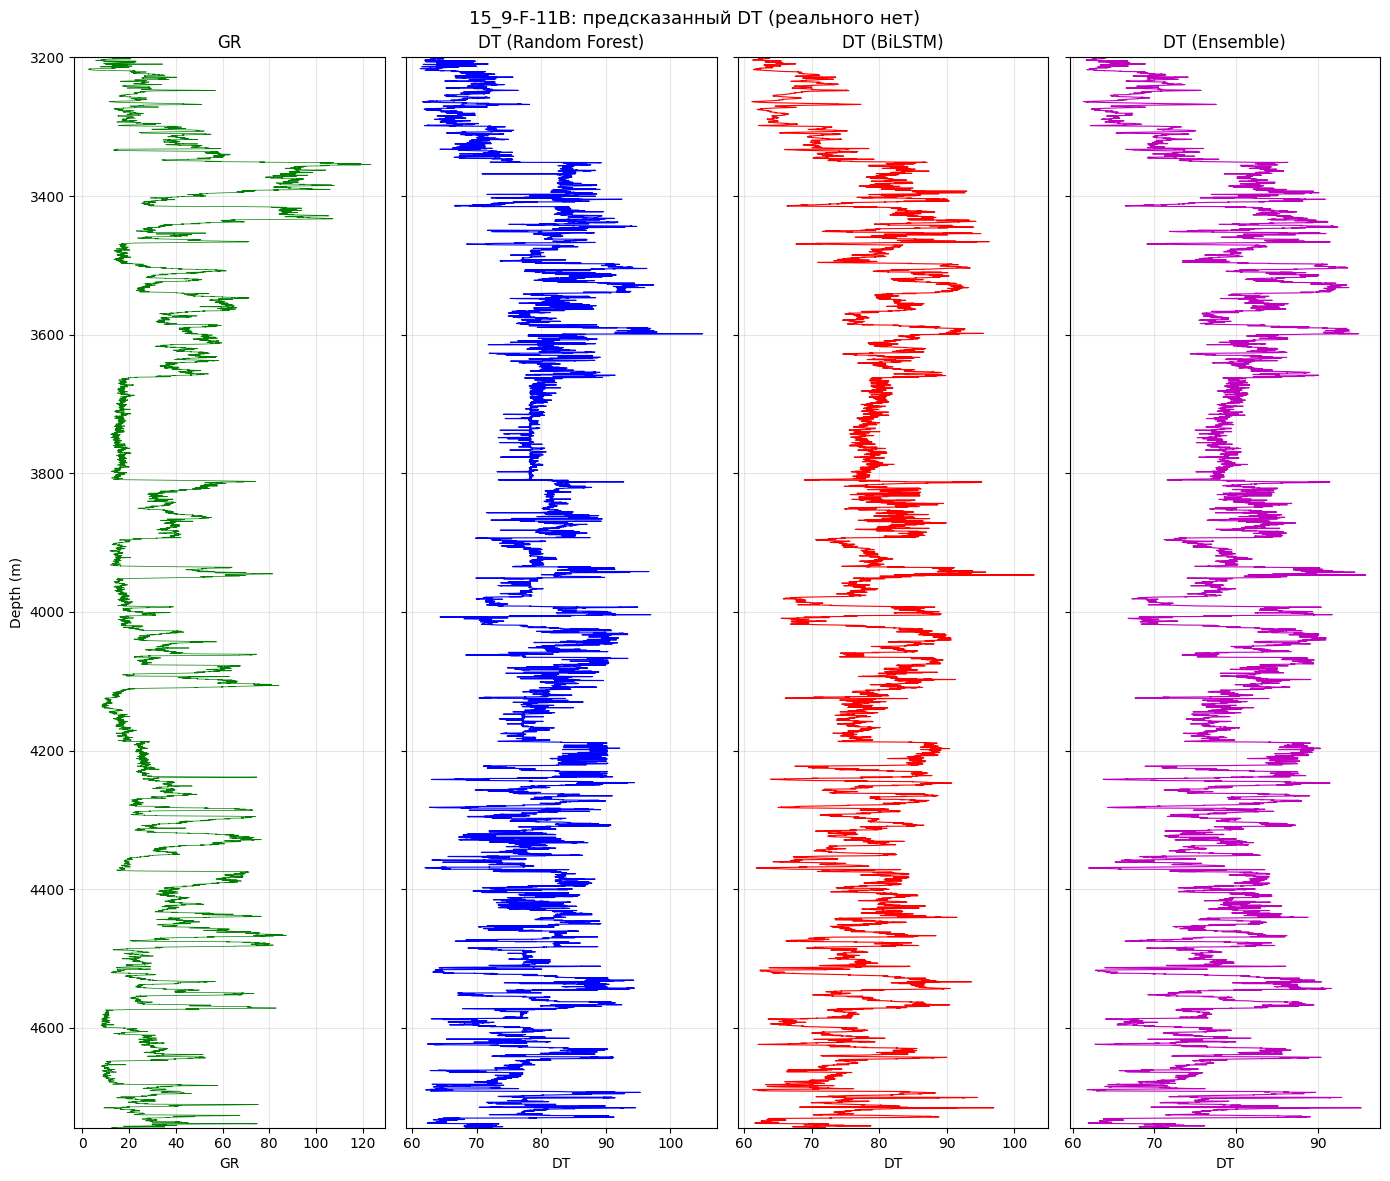

15_9-F-11B: предсказано 15456 точек
  DT (ensemble): 61.3 — 95.9 мкс/фт
  DT mean: 78.6



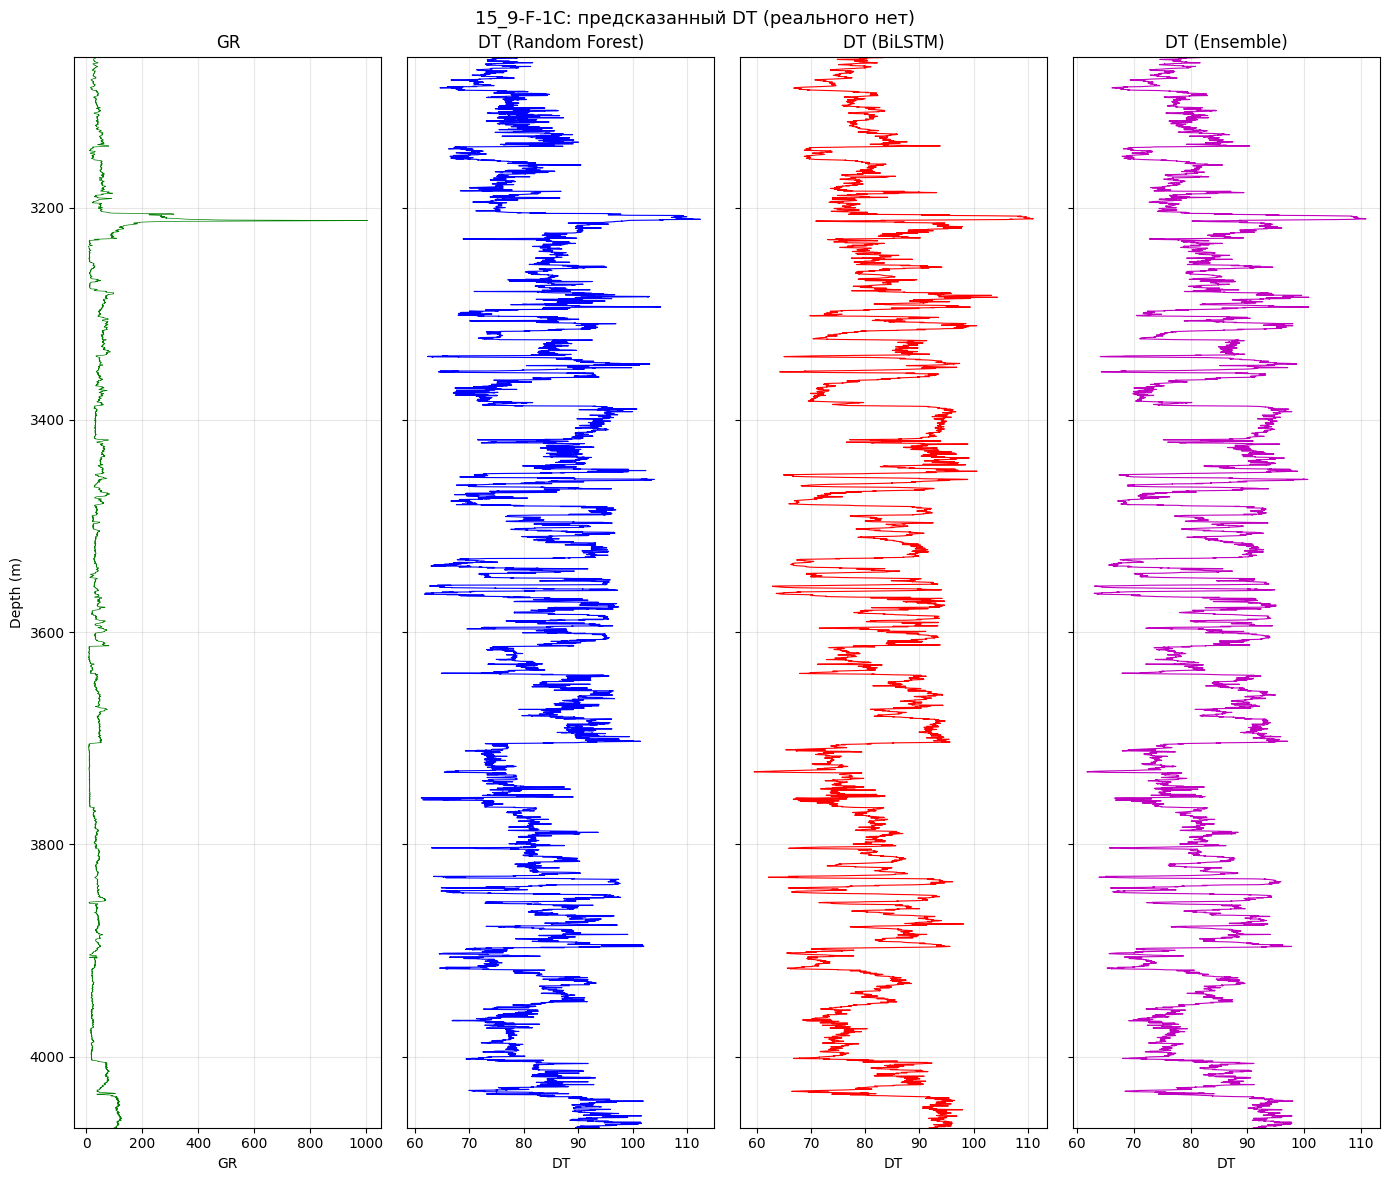

15_9-F-1C: предсказано 10093 точек
  DT (ensemble): 61.7 — 110.9 мкс/фт
  DT mean: 82.6



In [36]:
# Теперь предсказываем DT на F-11B и F-1C (где его нет)

for name, df in predict_wells_data.items():
    # Подготовка фичей
    df_aug = add_gradient_features(df, FEATURES)

    # Нормализация
    for col in FEATURES_AUG:
        if col in df_aug.columns:
            df_aug[col] = (df_aug[col] - feat_mean2[col]) / feat_std2[col]

    # RF предсказание
    df_orig = predict_wells_data[name]
    rf_pred_well = rf.predict(df_orig[FEATURES])

    # LSTM предсказание
    X_pred, _ = make_log_windows_v2(
        df_aug, FEATURES_AUG, FEATURES_AUG[0], WINDOW2  # target не важен
    )
    X_pred_t = torch.FloatTensor(X_pred)

    model2.eval()
    with torch.no_grad():
        lstm_pred_well = model2(X_pred_t).numpy().flatten()
    lstm_pred_well = lstm_pred_well * target_std + target_mean

    # Ensemble
    h2 = WINDOW2 // 2
    rf_trim = rf_pred_well[h2 : len(rf_pred_well) - h2]
    min_l = min(len(lstm_pred_well), len(rf_trim))
    final_pred = best_alpha * rf_trim[:min_l] + (1 - best_alpha) * lstm_pred_well[:min_l]
    depth_pred = df['DEPTH'].values[h2 : h2 + min_l]

    # Каротажный график
    fig, axes = plt.subplots(1, 4, figsize=(14, 12), sharey=True)

    # GR
    gr_well = df_orig['GR'].values[h2 : h2 + min_l]
    axes[0].plot(gr_well, depth_pred, 'g-', linewidth=0.5)
    axes[0].set_xlabel('GR')
    axes[0].set_title('GR')
    axes[0].set_ylim(depth_pred.max(), depth_pred.min())
    axes[0].set_ylabel('Depth (m)')
    axes[0].grid(True, alpha=0.3)

    # RF
    axes[1].plot(rf_trim[:min_l], depth_pred, 'b-', linewidth=0.8)
    axes[1].set_xlabel('DT')
    axes[1].set_title('DT (Random Forest)')
    axes[1].grid(True, alpha=0.3)

    # LSTM
    axes[2].plot(lstm_pred_well[:min_l], depth_pred, 'r-', linewidth=0.8)
    axes[2].set_xlabel('DT')
    axes[2].set_title('DT (BiLSTM)')
    axes[2].grid(True, alpha=0.3)

    # Ensemble
    axes[3].plot(final_pred, depth_pred, 'm-', linewidth=0.8)
    axes[3].set_xlabel('DT')
    axes[3].set_title('DT (Ensemble)')
    axes[3].grid(True, alpha=0.3)

    plt.suptitle(f'{name}: предсказанный DT (реального нет)', fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f"{name}: предсказано {min_l} точек")
    print(f"  DT (ensemble): {final_pred.min():.1f} — {final_pred.max():.1f} мкс/фт")
    print(f"  DT mean: {final_pred.mean():.1f}\n")